# Adding Task (T=1000) — Global Field Sobol Sensitivity Analysis
### Post-hoc analysis of completed sweep from `Adding_sobol_orchestrator.py`

**Research Context:** This notebook analyses the sensitivity of the JitteredFeedbackCell GF mechanism on the Adding Task (T=1000) — a canonical test of representational interference resistance. The sweep characterises which GF parameters most determine whether the network escapes the mean-prediction trap (MSE≈0.16) and achieves selective retention of marked values.

## 1. Libraries & Aesthetic Setup

In [2]:
import json
import math
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from scipy.ndimage import gaussian_filter1d

from SALib.sample import saltelli
from SALib.analyze import sobol

# ── Thesis aesthetics ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.2,
    'grid.linestyle': '--',
})
sns.set_style('whitegrid')

# ── Colour palette consistent with GF dissertation theme ───────────────────
C = {
    'active':    '#2980b9',   # blue  — active / complete runs
    'passive':   '#7f8c8d',   # grey  — passive / probe
    'exploded':  '#e74c3c',   # red   — failed / exploded
    'rank':      '#3498db',   # blue  — effective rank
    'sync':      '#e67e22',   # orange — synchrony
    'intf':      '#9b59b6',   # purple — interference
    'acorr':     '#1abc9c',   # teal   — autocorrelation
    'entropy':   '#f39c12',   # amber  — entropy
    'mse':       '#2ecc71',   # green  — MSE / performance
    'goldilocks':'#f1c40f',   # yellow — optimal zone
}

PARAM_LABELS = {
    'lambda':   r'$\lambda$ (Decay)',
    'inertia':  r'$H_{inertia}$',
    'strength': r'$S$ (Coupling)',
    'period':   r'$T_p$ (Period)',
    'jitter':   r'$\xi$ (Jitter)',
}

SAVE_DIR = '/home/casper/sobol_adding_backup/figures'
os.makedirs(SAVE_DIR, exist_ok=True)

def save_fig(name, fig=None):
    f = fig or plt.gcf()
    f.savefig(os.path.join(SAVE_DIR, f'{name}.pdf'), bbox_inches='tight')
    f.savefig(os.path.join(SAVE_DIR, f'{name}.png'), bbox_inches='tight', dpi=300)
    print(f'Saved: {name}')

print('Libraries loaded. Thesis aesthetics active.')

Libraries loaded. Thesis aesthetics active.


## 2. Data Loading & Pre-processing

In [3]:
ROOT = '/home/casper/Documents/A_Casper/Brein/CS_Ai_Wolfhampton/Dissertation/Adding_problem/SOBOL96_H128/'

# ── Load raw sweep data ────────────────────────────────────────────────────
with open(os.path.join(ROOT, 'SOBOL_FULL_HISTORY.json'), 'r') as f:
    raw = json.load(f)

with open(os.path.join(ROOT, 'SOBOL_PROGRESS_Y.json'), 'r') as f:
    Y_raw = json.load(f)

print(f'Total runs in history : {len(raw)}')
print(f'Total Y values        : {len(Y_raw)}')

# ── Reconstruct Sobol problem (must match worker exactly) ─────────────────
T = 1000
sobol_problem = {
    'num_vars': 5,
    'names': ['LAMBDA_SLOW', 'H_INERTIA', 'BASE_STRENGTH', 'PERIOD', 'JITTER_SCALE'],
    'bounds': [
        [0.0001, 0.0015],
        [0.92,   0.99],
        [0.02,   0.15],
        [T*1.0,  T*5.0],
        [0.01,   0.10]
    ]
}
N_baseline = 8
param_values = saltelli.sample(sobol_problem, N_baseline)
print(f'Saltelli matrix shape : {param_values.shape}  (expected {N_baseline*(2*5+2)} rows)')

Total runs in history : 96
Total Y values        : 96
Saltelli matrix shape : (96, 5)  (expected 96 rows)


In [4]:
# ── Build flat DataFrame from run histories ────────────────────────────────
records = []
for run in raw:
    rid    = run['run_id']
    status = run.get('status', 'unknown')
    params = run.get('parameters', {})
    epochs = run.get('epochs', [])

    # Extract last valid epoch metrics
    if epochs:
        last = epochs[-1]
        rec = {
            'run_id':   rid,
            'status':   status,
            'survived': 1 if status == 'complete' else 0,
            'n_epochs': len(epochs),
            # parameters
            'lambda':   params.get('lambda',   np.nan),
            'inertia':  params.get('inertia',  np.nan),
            'strength': params.get('strength', np.nan),
            'period':   params.get('period',   np.nan),
            'jitter':   params.get('jitter',   np.nan),
            # final metrics
            'mse':      last.get('mse',     np.nan),
            'rank':     last.get('rank',    np.nan),
            'sync':     last.get('sync',    np.nan),
            'acorr':    last.get('acorr',   np.nan),
            'intf':     last.get('intf',    np.nan),
            'entropy':  last.get('entropy', np.nan),
            # best epoch metrics (minimum MSE achieved)
            'best_mse': min(e.get('mse', 999) for e in epochs),
        }
        records.append(rec)

df = pd.DataFrame(records).sort_values('run_id').reset_index(drop=True)

# ── Status summary ─────────────────────────────────────────────────────────
print('\nStatus breakdown:')
print(df['status'].value_counts())
print(f'\nMean task: {len(df)} runs parsed')
print(f'MSE range (complete): {df[df.survived==1]["mse"].min():.4f} — {df[df.survived==1]["mse"].max():.4f}')
print(f'Baseline MSE (predict mean): ~0.1667')
df.head()


Status breakdown:
status
complete    66
exploded    28
failed       2
Name: count, dtype: int64

Mean task: 96 runs parsed
MSE range (complete): 0.0100 — 0.0833
Baseline MSE (predict mean): ~0.1667


,run_id,status,survived,n_epochs,lambda,inertia,strength,period,jitter,mse,rank,sync,acorr,intf,entropy,best_mse
0,0,exploded,0,60,0.000231,0.952813,0.080938,3625.0,0.035313,NaN,NaN,NaN,NaN,NaN,NaN,0.070021
1,1,complete,1,150,0.001456,0.952813,0.080938,3625.0,0.035313,0.028691,2.275431,0.647592,0.649221,0.089843,-0.379724,0.020385
2,2,complete,1,150,0.000231,0.957187,0.080938,3625.0,0.035313,0.020146,3.387633,0.580715,0.601024,0.126126,-1.410876,0.014455
3,3,complete,1,150,0.000231,0.952813,0.129688,3625.0,0.035313,0.023444,2.943313,0.623518,0.612552,0.113501,-1.117093,0.018133
4,4,complete,1,150,0.000231,0.952813,0.080938,2875.0,0.035313,0.012478,2.947229,0.592856,0.625900,0.082345,-1.142485,0.012333


In [5]:
# ── Build Y arrays for SALib — NaN penalty strategy ───────────────────────
# Replace NaN / exploded MSE with 2 × max valid MSE (encodes instability boundary)
Y_arr = np.array(Y_raw, dtype=float)

valid_mask   = np.isfinite(Y_arr) & (Y_arr < 10.0)
penalty_val  = 2.0 * np.nanmax(Y_arr[valid_mask]) if valid_mask.any() else 2.0
Y_penalised  = np.where(np.isfinite(Y_arr) & (Y_arr < 10.0), Y_arr, penalty_val)

print(f'Total Y entries   : {len(Y_arr)}')
print(f'Valid (finite<10) : {valid_mask.sum()}')
print(f'Penalised (NaN/∞) : {(~valid_mask).sum()}')
print(f'Penalty value     : {penalty_val:.4f}')
print(f'Y_penalised shape : {Y_penalised.shape}')

Total Y entries   : 96
Valid (finite<10) : 68
Penalised (NaN/∞) : 28
Penalty value     : 0.3204
Y_penalised shape : (96,)


## 3. Sobol Sensitivity Analysis

In [6]:
# ── Run SALib Sobol analysis on MSE ───────────────────────────────────────
Si_mse = sobol.analyze(sobol_problem, Y_penalised, calc_second_order=True, print_to_console=False)

param_names = sobol_problem['names']

# Integrated label mapping (Handles case-sensitivity and cleanup)
label_map = {
    'LAMBDA_SLOW':   r'$\lambda$ (Decay)',
    'H_INERTIA':     r'${Inertia}$',
    'BASE_STRENGTH': r'$S$ (Coupling)',
    'PERIOD':        r'$T_p$ (Period)',
    'JITTER_SCALE':  r'$\xi$ (Jitter)',
}

# Use .get() to avoid KeyErrors if a name is slightly different
nice_labels = [label_map.get(n, n) for n in param_names]

print('Sobol Indices — MSE (Total Order ST):')
for name, st, st_c in zip(param_names, Si_mse['ST'], Si_mse['ST_conf']):
    print(f'  {name:<18}: ST={st:.4f}  ±{st_c:.4f}')

Sobol Indices — MSE (Total Order ST):
  LAMBDA_SLOW       : ST=0.7867  ±0.8065
  H_INERTIA         : ST=1.5797  ±0.6007
  BASE_STRENGTH     : ST=0.3598  ±0.4736
  PERIOD            : ST=0.3010  ±0.5157
  JITTER_SCALE      : ST=0.2754  ±0.4750


In [7]:
# ── Build Sobol indices for representational metrics ──────────────────────
# Align df metrics with the full Saltelli matrix by run_id
def build_Y_metric(metric_col, df, n_total, penalty=None):
    """Map df metric values onto the full Saltelli index array."""
    Y = np.full(n_total, np.nan)
    for _, row in df.iterrows():
        rid = int(row['run_id'])
        if rid < n_total:
            Y[rid] = row[metric_col]
    if penalty is None:
        p = 2.0 * np.nanmax(Y[np.isfinite(Y)]) if np.any(np.isfinite(Y)) else 0.0
    else:
        p = penalty
    Y = np.where(np.isfinite(Y), Y, p)
    return Y

n_total = len(Y_penalised)

Y_rank = build_Y_metric('rank', df, n_total)
Y_sync = build_Y_metric('sync', df, n_total)
Y_intf = build_Y_metric('intf', df, n_total)
Y_acorr= build_Y_metric('acorr', df, n_total)
Y_entr = build_Y_metric('entropy', df, n_total)
Y_surv = build_Y_metric('survived', df, n_total, penalty=0)

# Change these to True to match your sampling/MSE analysis
Si_rank = sobol.analyze(sobol_problem, Y_rank,  calc_second_order=True, print_to_console=False)
Si_sync = sobol.analyze(sobol_problem, Y_sync,  calc_second_order=True, print_to_console=False)
Si_intf = sobol.analyze(sobol_problem, Y_intf,  calc_second_order=True, print_to_console=False)
Si_surv = sobol.analyze(sobol_problem, Y_surv,  calc_second_order=True, print_to_console=False)

print('Sobol indices computed for: MSE, Rank, Sync, Interference, Survival')

Sobol indices computed for: MSE, Rank, Sync, Interference, Survival


## 4. Visualisation Suite

### 4.1  Sobol Bar Charts — S1 and ST

Saved: sobol_bar_all_metrics


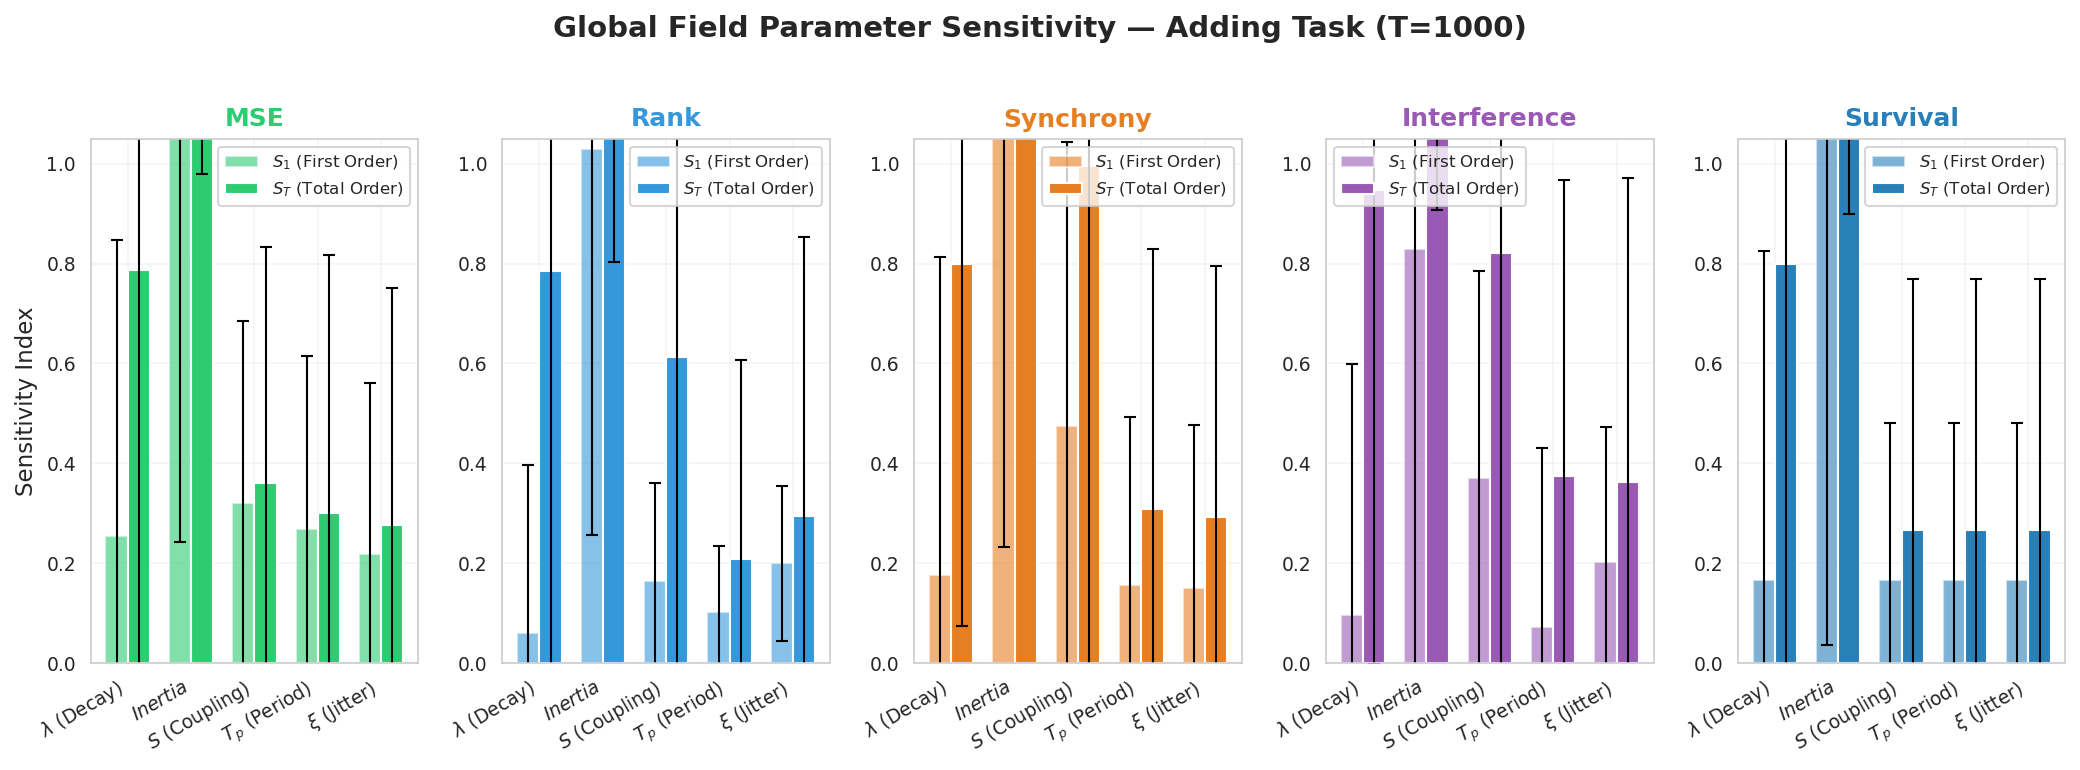

In [8]:
def plot_sobol_bars(Si_dict, labels, title='Sobol Sensitivity Indices', figsize=(14, 5)):
    """
    Side-by-side S1 / ST bar charts for multiple output metrics.
    Si_dict: {metric_name: SALib Si result}
    """
    metric_colors = {
        'MSE':          C['mse'],
        'Rank':         C['rank'],
        'Synchrony':    C['sync'],
        'Interference': C['intf'],
        'Survival':     C['active'],
    }

    n_metrics = len(Si_dict)
    fig, axes = plt.subplots(1, n_metrics, figsize=figsize, sharey=False)
    if n_metrics == 1:
        axes = [axes]

    x = np.arange(len(labels))
    w = 0.35

    for ax, (metric, Si) in zip(axes, Si_dict.items()):
        col = metric_colors.get(metric, '#555')
        s1  = np.clip(Si['S1'], 0, None)
        st  = np.clip(Si['ST'], 0, None)
        s1c = Si['S1_conf']
        stc = Si['ST_conf']

        ax.bar(x - w/2, s1, w, label='$S_1$ (First Order)',
               color=col, alpha=0.6, yerr=s1c, capsize=3, error_kw={'linewidth':1})
        ax.bar(x + w/2, st, w, label='$S_T$ (Total Order)',
               color=col, alpha=1.0, yerr=stc, capsize=3, error_kw={'linewidth':1})

        ax.set_title(metric, fontsize=12, fontweight='bold', color=col)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=30, ha='right')
        ax.set_ylim(0, 1.05)
        ax.set_ylabel('Sensitivity Index' if ax == axes[0] else '')
        ax.axhline(0, color='black', linewidth=0.5)
        ax.legend(fontsize=8)

    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    fig.tight_layout()
    return fig

fig = plot_sobol_bars(
    Si_dict={
        'MSE':          Si_mse,
        'Rank':         Si_rank,
        'Synchrony':    Si_sync,
        'Interference': Si_intf,
        'Survival':     Si_surv,
    },
    labels=nice_labels,
    title='Global Field Parameter Sensitivity — Adding Task (T=1000)'
)
save_fig('sobol_bar_all_metrics', fig)
plt.show()

### 4.2  Second-Order Interaction Heatmap (MSE)


Second-Order Interactions (MSE) Matrix
                   $\lambda$ (Decay)  ${Inertia}$  $S$ (Coupling)  \
$\lambda$ (Decay)             0.0000      -0.2473         -0.2311   
${Inertia}$                  -0.2473       0.0000         -0.2408   
$S$ (Coupling)               -0.2311      -0.2408          0.0000   
$T_p$ (Period)               -0.2326      -0.0115         -0.1532   
$\xi$ (Jitter)               -0.2301       0.0588         -0.1454   

                   $T_p$ (Period)  $\xi$ (Jitter)  
$\lambda$ (Decay)         -0.2326         -0.2301  
${Inertia}$               -0.0115          0.0588  
$S$ (Coupling)            -0.1532         -0.1454  
$T_p$ (Period)             0.0000         -0.1206  
$\xi$ (Jitter)            -0.1206          0.0000  



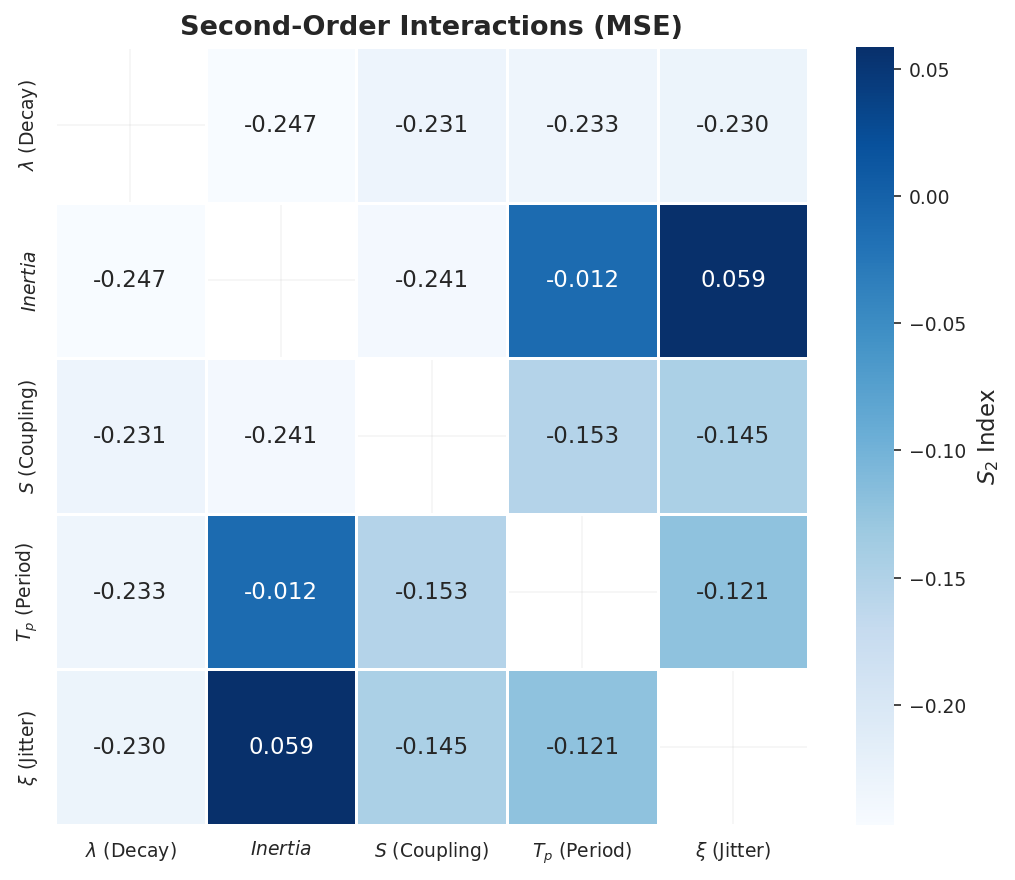

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_s2_heatmap(Si, labels, title='Second-Order Interactions (MSE)'):
    S2 = Si.get('S2', None)
    if S2 is None:
        print('S2 not available — run SALib with calc_second_order=True')
        return

    n = len(labels)
    mat = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            v = S2[i, j]
            mat[i, j] = v
            mat[j, i] = v

    # --- Print Matrix to Terminal ---
    # We use a DataFrame here to keep the labels attached to the values
    df_s2 = pd.DataFrame(mat, index=labels, columns=labels)
    print(f"\n{'='*20}")
    print(f"{title} Matrix")
    print(f"{'='*20}")
    print(df_s2.round(4)) # Rounding for terminal cleanliness
    print(f"{'='*20}\n")

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(7, 6))
    mask = np.eye(n, dtype=bool)
    sns.heatmap(mat, annot=True, fmt='.3f', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                mask=mask, ax=ax, linewidths=0.5,
                cbar_kws={'label': '$S_2$ Index'})
    ax.set_title(title, fontsize=13, fontweight='bold')
    fig.tight_layout()
    # save_fig('sobol_s2_heatmap', fig) # Uncomment if save_fig is defined
    plt.show()

plot_s2_heatmap(Si_mse, nice_labels)

### 4.3  Survival / Explosion Map

Saved: survival_map


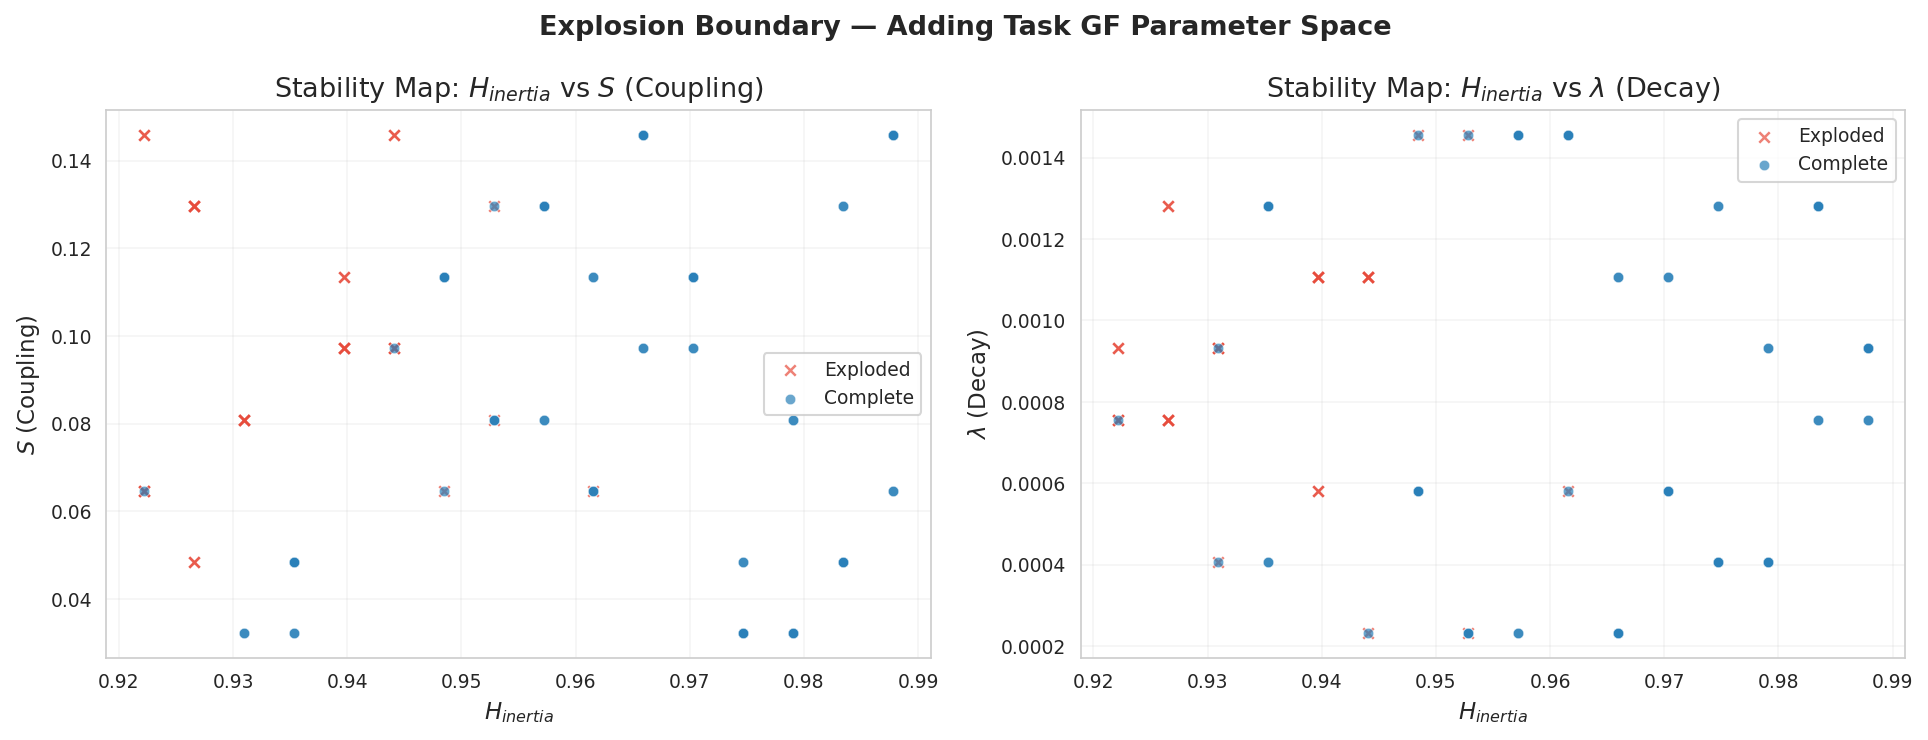

In [10]:
def plot_survival_map(df):
    """
    2D scatter: which parameter combinations survive vs explode.
    The two most sensitive parameters from ST (usually inertia × strength) on axes.
    """
    complete  = df[df.survived == 1]
    exploded  = df[df.survived == 0]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, (xp, yp) in zip(axes, [('inertia', 'strength'), ('inertia', 'lambda')]):
        ax.scatter(exploded[xp], exploded[yp], c=C['exploded'], s=25,
                   alpha=0.7, label='Exploded', marker='x', linewidths=1.2)
        ax.scatter(complete[xp],  complete[yp],  c=C['active'],   s=25,
                   alpha=0.7, label='Complete',  marker='o', edgecolors='white', linewidths=0.3)
        ax.set_xlabel(PARAM_LABELS.get(xp, xp))
        ax.set_ylabel(PARAM_LABELS.get(yp, yp))
        ax.set_title(f'Stability Map: {PARAM_LABELS.get(xp,xp)} vs {PARAM_LABELS.get(yp,yp)}')
        ax.legend()

    fig.suptitle('Explosion Boundary — Adding Task GF Parameter Space', fontsize=13, fontweight='bold')
    fig.tight_layout()
    save_fig('survival_map', fig)
    plt.show()

plot_survival_map(df)

### 4.4  Parallel Coordinates — Complete vs Exploded

Saved: parallel_coords


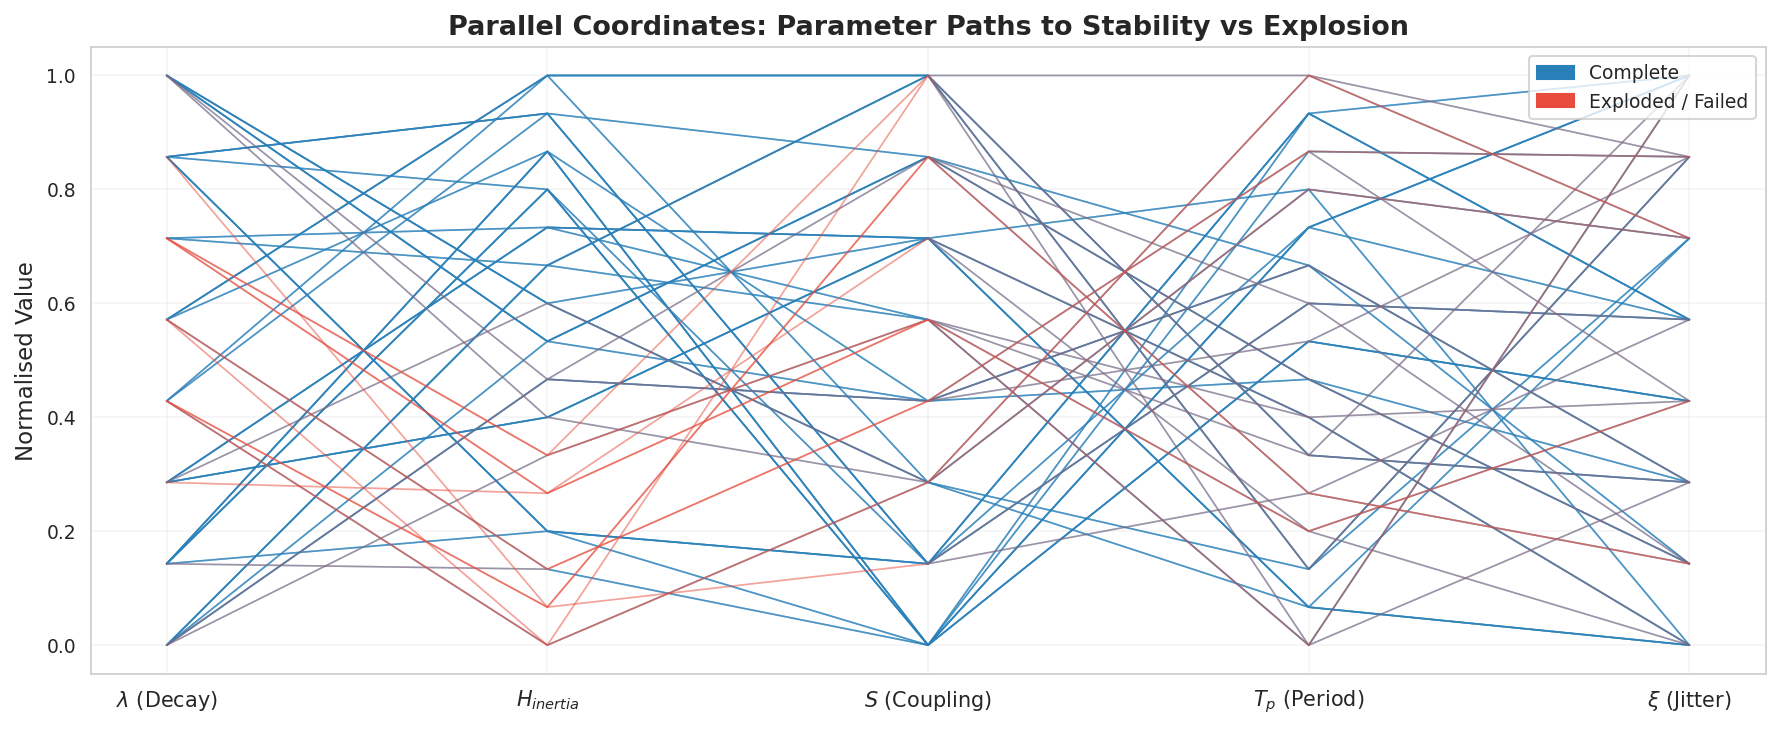

In [11]:
def plot_parallel_coords(df):
    from pandas.plotting import parallel_coordinates

    param_cols = ['lambda', 'inertia', 'strength', 'period', 'jitter']
    plot_df = df[param_cols + ['status']].copy()

    # Normalise each parameter to [0, 1] for readable axes
    for col in param_cols:
        mn, mx = plot_df[col].min(), plot_df[col].max()
        plot_df[col] = (plot_df[col] - mn) / (mx - mn + 1e-12)

    fig, ax = plt.subplots(figsize=(12, 5))

    color_map = {'complete': C['active'], 'failed': C['exploded'], 'exploded': C['exploded']}

    for status, grp in plot_df.groupby('status'):
        col = color_map.get(status, C['passive'])
        alpha = 0.6 if status == 'complete' else 0.3
        for _, row in grp.iterrows():
            ax.plot(range(len(param_cols)), row[param_cols].values,
                    color=col, alpha=alpha, linewidth=0.8)

    ax.set_xticks(range(len(param_cols)))
    ax.set_xticklabels([PARAM_LABELS.get(p, p) for p in param_cols], fontsize=10)
    ax.set_ylabel('Normalised Value')
    ax.set_title('Parallel Coordinates: Parameter Paths to Stability vs Explosion',
                 fontsize=13, fontweight='bold')

    legend_elements = [
        mpatches.Patch(color=C['active'],   label='Complete'),
        mpatches.Patch(color=C['exploded'], label='Exploded / Failed'),
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    fig.tight_layout()
    save_fig('parallel_coords', fig)
    plt.show()

plot_parallel_coords(df)

### 4.5  Bifurcation Analysis — Inertia vs MSE / Rank

Saved: bifurcation_inertia


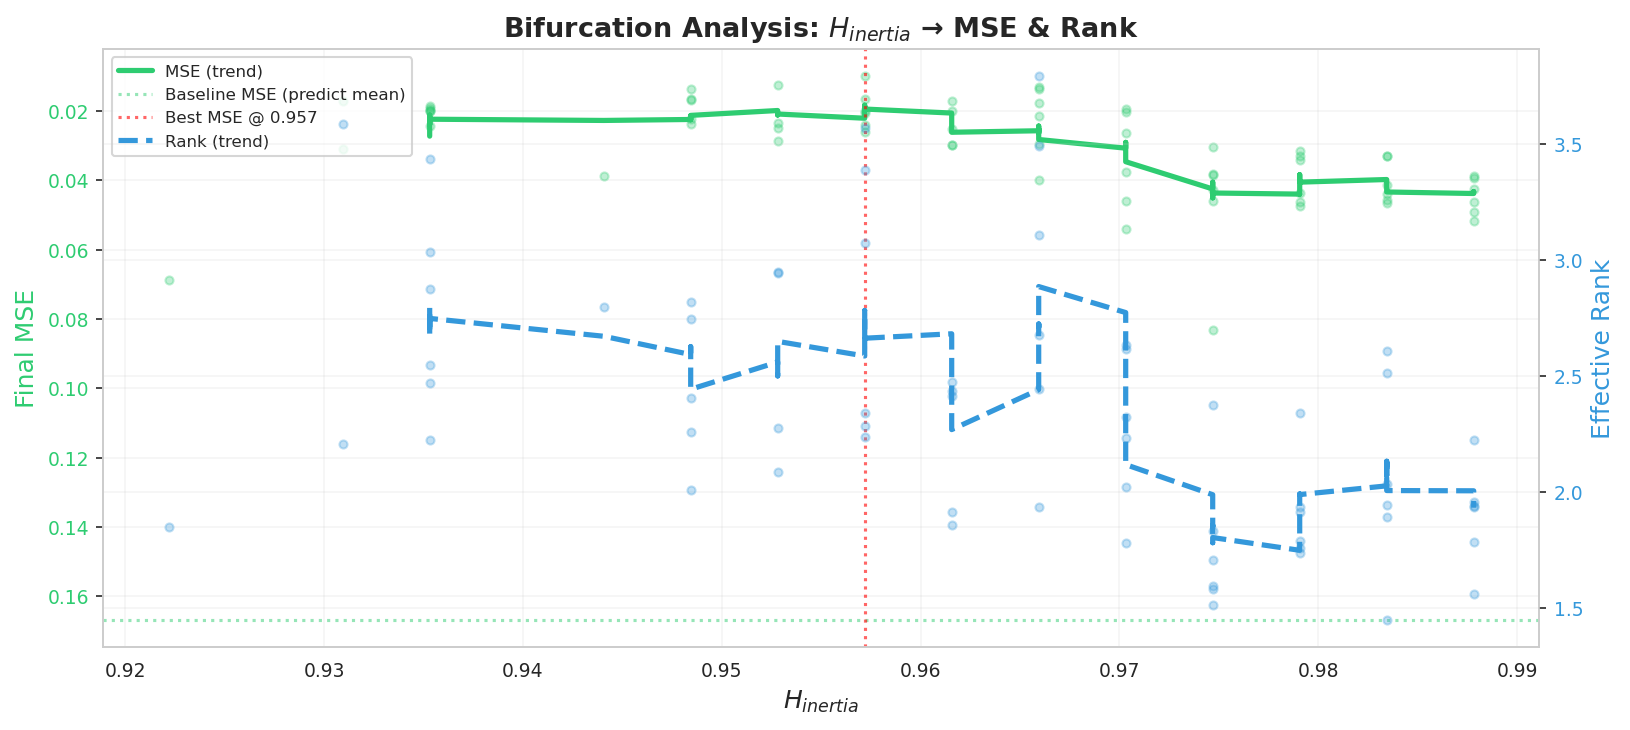

Saved: bifurcation_strength


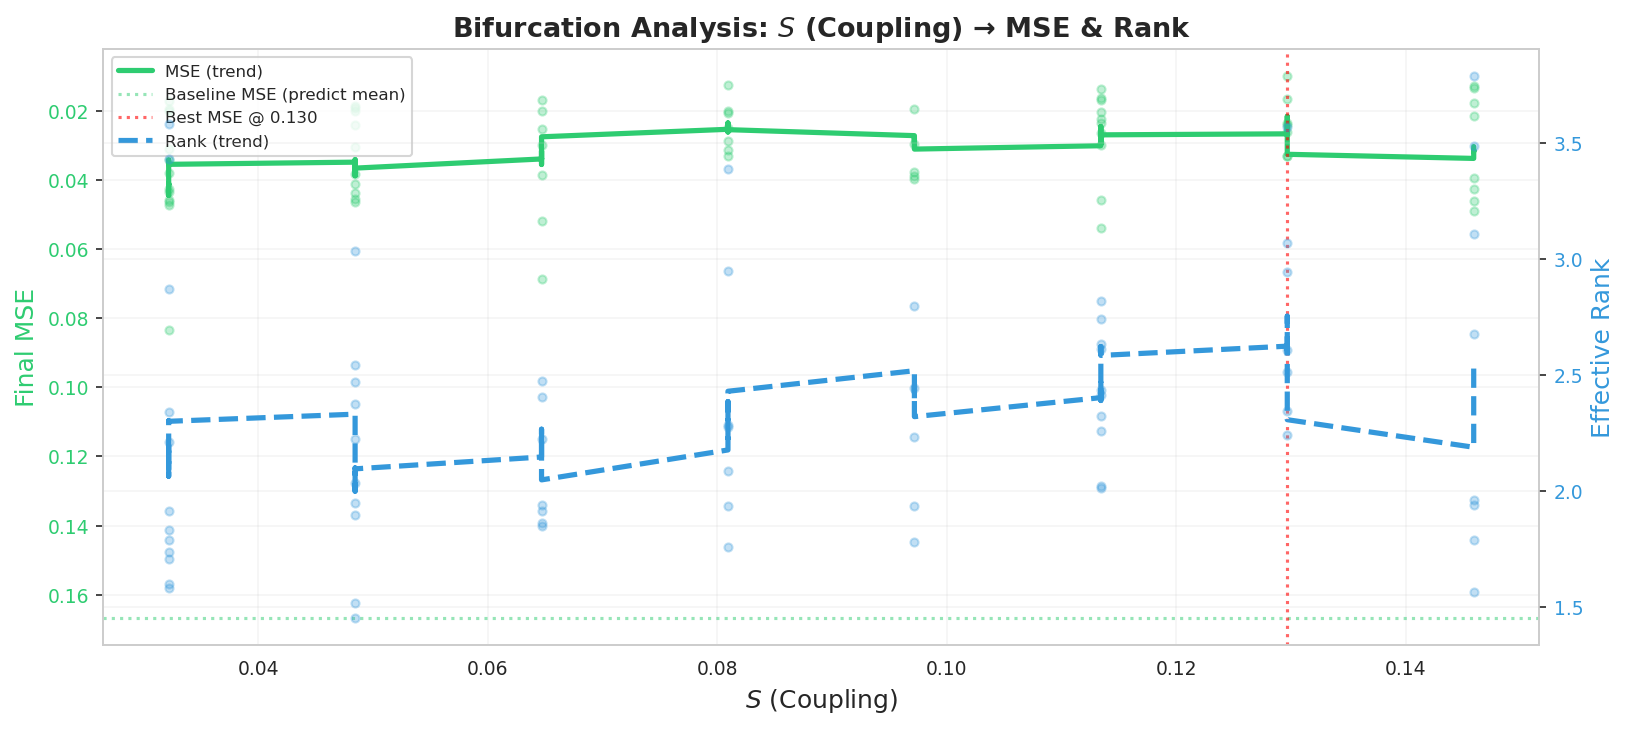

In [12]:
def plot_bifurcation(df, x_param='inertia', window=8):
    df_s = df.sort_values(x_param)
    complete = df_s[df_s.survived == 1]

    fig, ax1 = plt.subplots(figsize=(11, 5))

    # MSE on left axis (lower = better, invert)
    ax1.set_xlabel(PARAM_LABELS.get(x_param, x_param), fontsize=12)
    ax1.set_ylabel('Final MSE', color=C['mse'], fontsize=12)
    ax1.scatter(complete[x_param], complete['mse'], color=C['mse'], s=15, alpha=0.3)
    if len(complete) >= window:
        rolled_mse = complete['mse'].rolling(window=window, center=True).mean()
        ax1.plot(complete[x_param], rolled_mse, color=C['mse'], linewidth=2.5, label='MSE (trend)')
    ax1.axhline(0.1667, color=C['mse'], linestyle=':', alpha=0.5, label='Baseline MSE (predict mean)')
    ax1.tick_params(axis='y', labelcolor=C['mse'])
    ax1.invert_yaxis()

    # Rank on right axis
    ax2 = ax1.twinx()
    ax2.set_ylabel('Effective Rank', color=C['rank'], fontsize=12)
    ax2.scatter(complete[x_param], complete['rank'], color=C['rank'], s=15, alpha=0.3)
    if len(complete) >= window:
        rolled_rank = complete['rank'].rolling(window=window, center=True).mean()
        ax2.plot(complete[x_param], rolled_rank, color=C['rank'], linewidth=2.5,
                 linestyle='--', label='Rank (trend)')
    ax2.tick_params(axis='y', labelcolor=C['rank'])

    # Mark the optimal point
    best_idx = complete['mse'].idxmin()
    if not pd.isna(best_idx):
        best_x = complete.loc[best_idx, x_param]
        ax1.axvline(best_x, color='red', linestyle=':', alpha=0.6, label=f'Best MSE @ {best_x:.3f}')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

    plt.title(f'Bifurcation Analysis: {PARAM_LABELS.get(x_param,x_param)} → MSE & Rank',
              fontsize=13, fontweight='bold')
    fig.tight_layout()
    save_fig(f'bifurcation_{x_param}', fig)
    plt.show()

plot_bifurcation(df, x_param='inertia')
plot_bifurcation(df, x_param='strength')

### 4.6  Synchrony Criticality — The Goldilocks Zone

Saved: synchrony_criticality


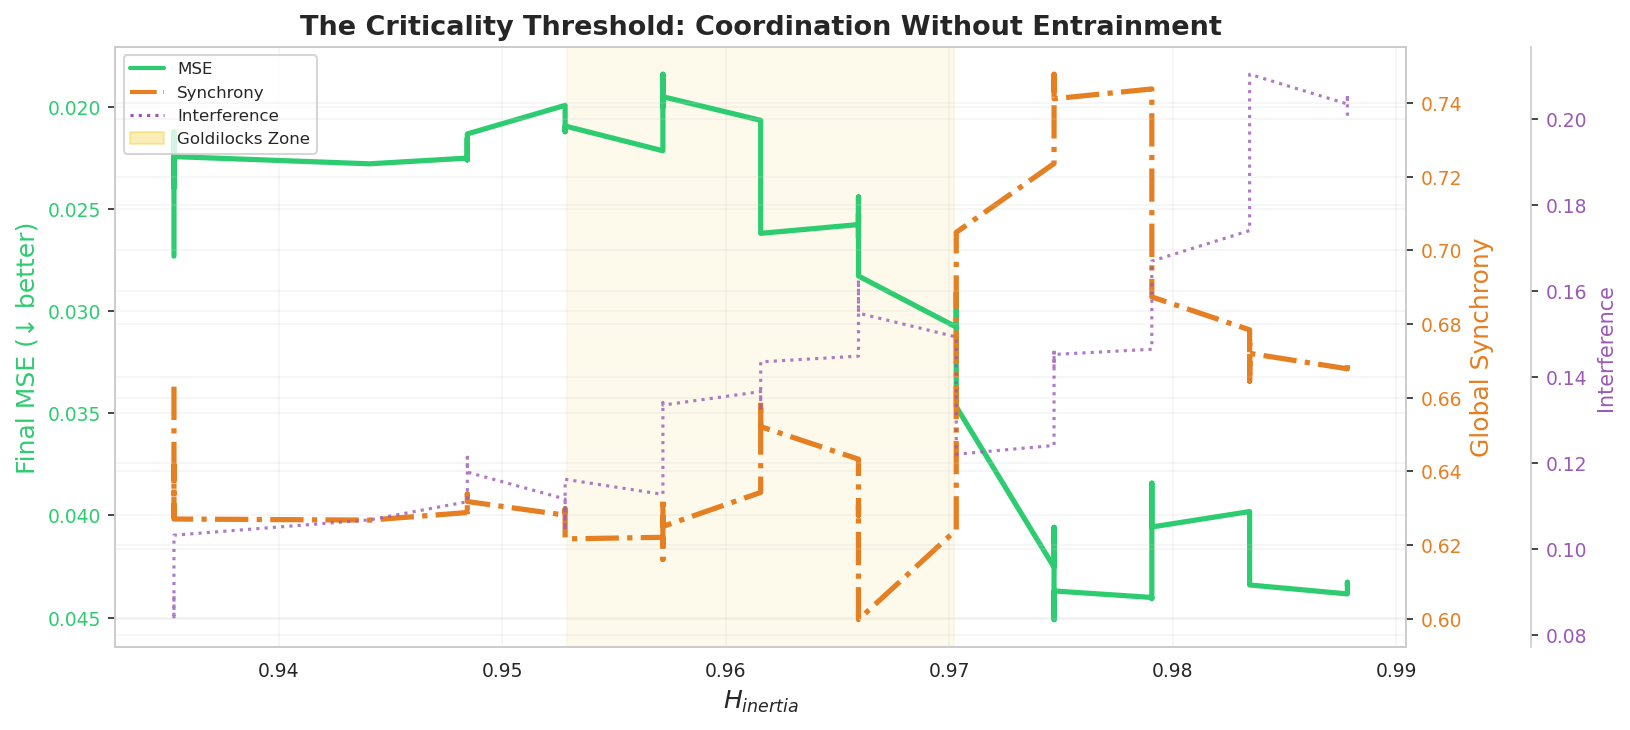

In [13]:
def plot_synchrony_criticality(df, x_param='inertia', window=8):
    df_s   = df.sort_values(x_param)
    complete = df_s[df_s.survived == 1]

    fig, ax1 = plt.subplots(figsize=(11, 5))

    # MSE
    ax1.set_xlabel(PARAM_LABELS.get(x_param, x_param), fontsize=12)
    ax1.set_ylabel('Final MSE (↓ better)', color=C['mse'], fontsize=12)
    if len(complete) >= window:
        ax1.plot(complete[x_param],
                 complete['mse'].rolling(window=window, center=True).mean(),
                 color=C['mse'], linewidth=2.5, label='MSE')
    ax1.tick_params(axis='y', labelcolor=C['mse'])
    ax1.invert_yaxis()

    # Synchrony
    ax2 = ax1.twinx()
    ax2.set_ylabel('Global Synchrony', color=C['sync'], fontsize=12)
    if len(complete) >= window:
        ax2.plot(complete[x_param],
                 complete['sync'].rolling(window=window, center=True).mean(),
                 color=C['sync'], linewidth=2.5, linestyle='-.', label='Synchrony')
    ax2.tick_params(axis='y', labelcolor=C['sync'])

    # Interference overlay
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    ax3.set_ylabel('Interference', color=C['intf'], fontsize=10)
    if len(complete) >= window:
        ax3.plot(complete[x_param],
                 complete['intf'].rolling(window=window, center=True).mean(),
                 color=C['intf'], linewidth=1.5, linestyle=':', label='Interference', alpha=0.8)
    ax3.tick_params(axis='y', labelcolor=C['intf'])

    # Goldilocks annotation
    xl = ax1.get_xlim()
    mid = (xl[0] + xl[1]) / 2
    span = (xl[1] - xl[0]) * 0.15
    ax1.axvspan(mid - span, mid + span, color=C['goldilocks'], alpha=0.08,
                label='Coordination-without-collapse zone')

    lines  = [plt.Line2D([0],[0], color=C['mse'],  lw=2, label='MSE'),
              plt.Line2D([0],[0], color=C['sync'], lw=2, ls='-.', label='Synchrony'),
              plt.Line2D([0],[0], color=C['intf'], lw=1.5, ls=':', label='Interference'),
              mpatches.Patch(color=C['goldilocks'], alpha=0.3, label='Goldilocks Zone')]
    ax1.legend(handles=lines, loc='upper left', fontsize=8)

    plt.title('The Criticality Threshold: Coordination Without Entrainment',
              fontsize=13, fontweight='bold')
    fig.tight_layout()
    save_fig('synchrony_criticality', fig)
    plt.show()

plot_synchrony_criticality(df, x_param='inertia')

### 4.7  Entropy × Rank Phase Portrait — Complete vs Exploded

Saved: rank_entropy_phase_portrait


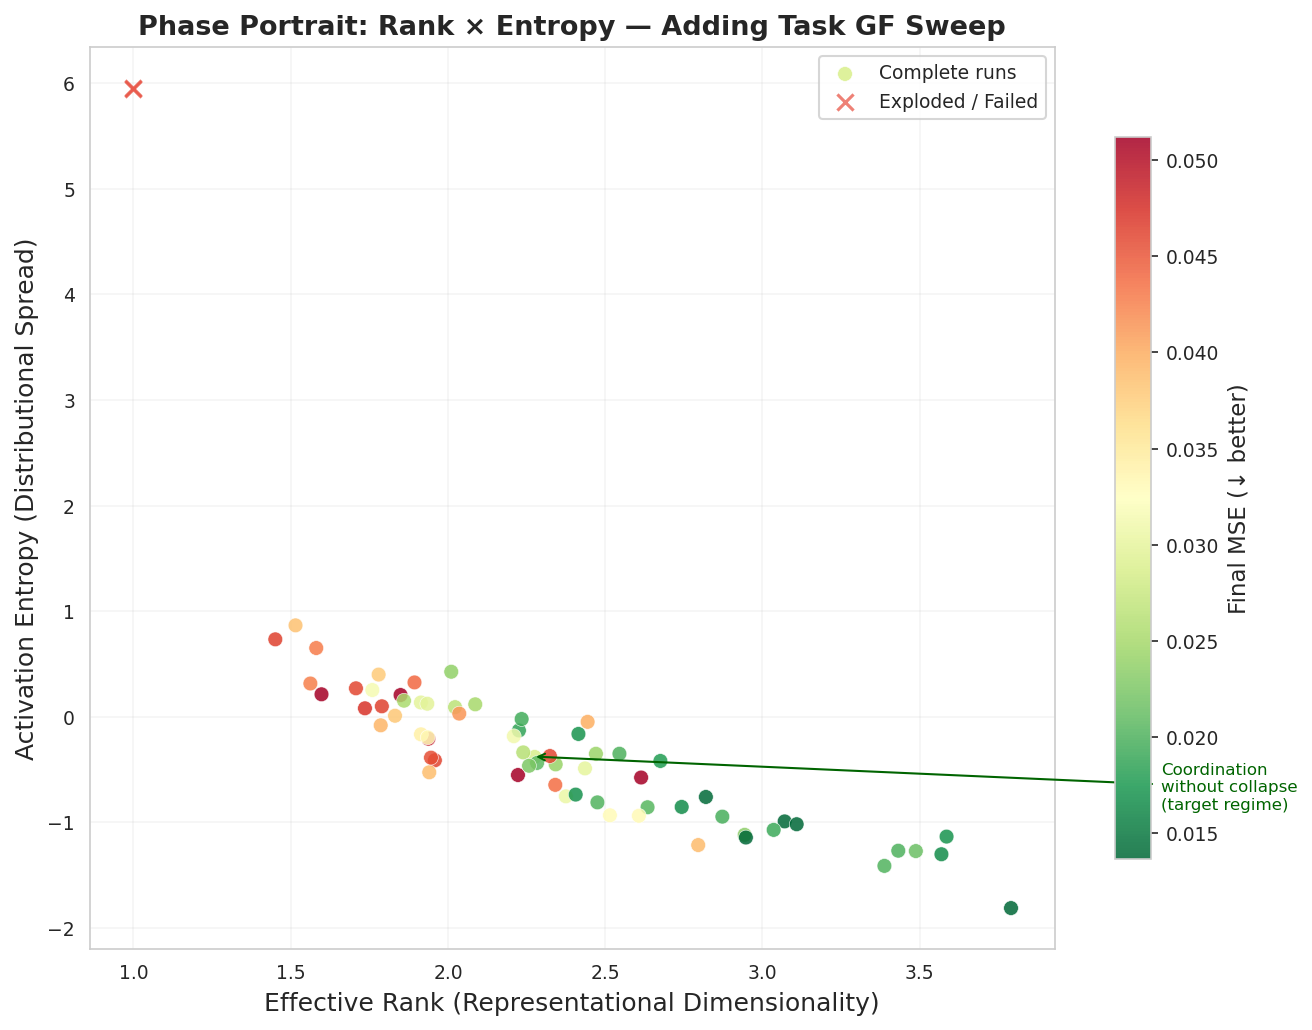

In [14]:
def plot_rank_entropy_phase(df):
    """
    Phase portrait: Entropy vs Effective Rank coloured by MSE.
    Exploded runs shown as X markers at low rank / low entropy.
    """
    complete = df[df.survived == 1].copy()
    exploded = df[df.survived == 0].copy()

    fig, ax = plt.subplots(figsize=(9, 7))

    # Complete runs — coloured by MSE
    sc = ax.scatter(complete['rank'], complete['entropy'],
                    c=complete['mse'], cmap='RdYlGn_r',
                    s=50, alpha=0.85, edgecolors='white', linewidths=0.3,
                    vmin=complete['mse'].quantile(0.05),
                    vmax=complete['mse'].quantile(0.95),
                    label='Complete runs', zorder=3)
    plt.colorbar(sc, ax=ax, label='Final MSE (↓ better)', shrink=0.8)

    # Exploded runs
    ax.scatter(exploded['rank'], exploded['entropy'],
               color=C['exploded'], marker='x', s=60, linewidths=1.5,
               alpha=0.7, label='Exploded / Failed', zorder=4)

    # Baseline MSE line annotation
    ax.set_xlabel('Effective Rank (Representational Dimensionality)', fontsize=12)
    ax.set_ylabel('Activation Entropy (Distributional Spread)', fontsize=12)
    ax.set_title('Phase Portrait: Rank × Entropy — Adding Task GF Sweep',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)

    # Annotate the coordination-without-collapse region
    ax.annotate('Coordination\nwithout collapse\n(target regime)',
                xy=(complete['rank'].median(), complete['entropy'].median()),
                xytext=(complete['rank'].median() + 2, complete['entropy'].median() - 0.5),
                fontsize=8, color='darkgreen',
                arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1))

    fig.tight_layout()
    save_fig('rank_entropy_phase_portrait', fig)
    plt.show()

plot_rank_entropy_phase(df)

### 4.8  GF State Transition Map (KDE: Inertia × Synchrony)

Saved: gf_state_transition_map


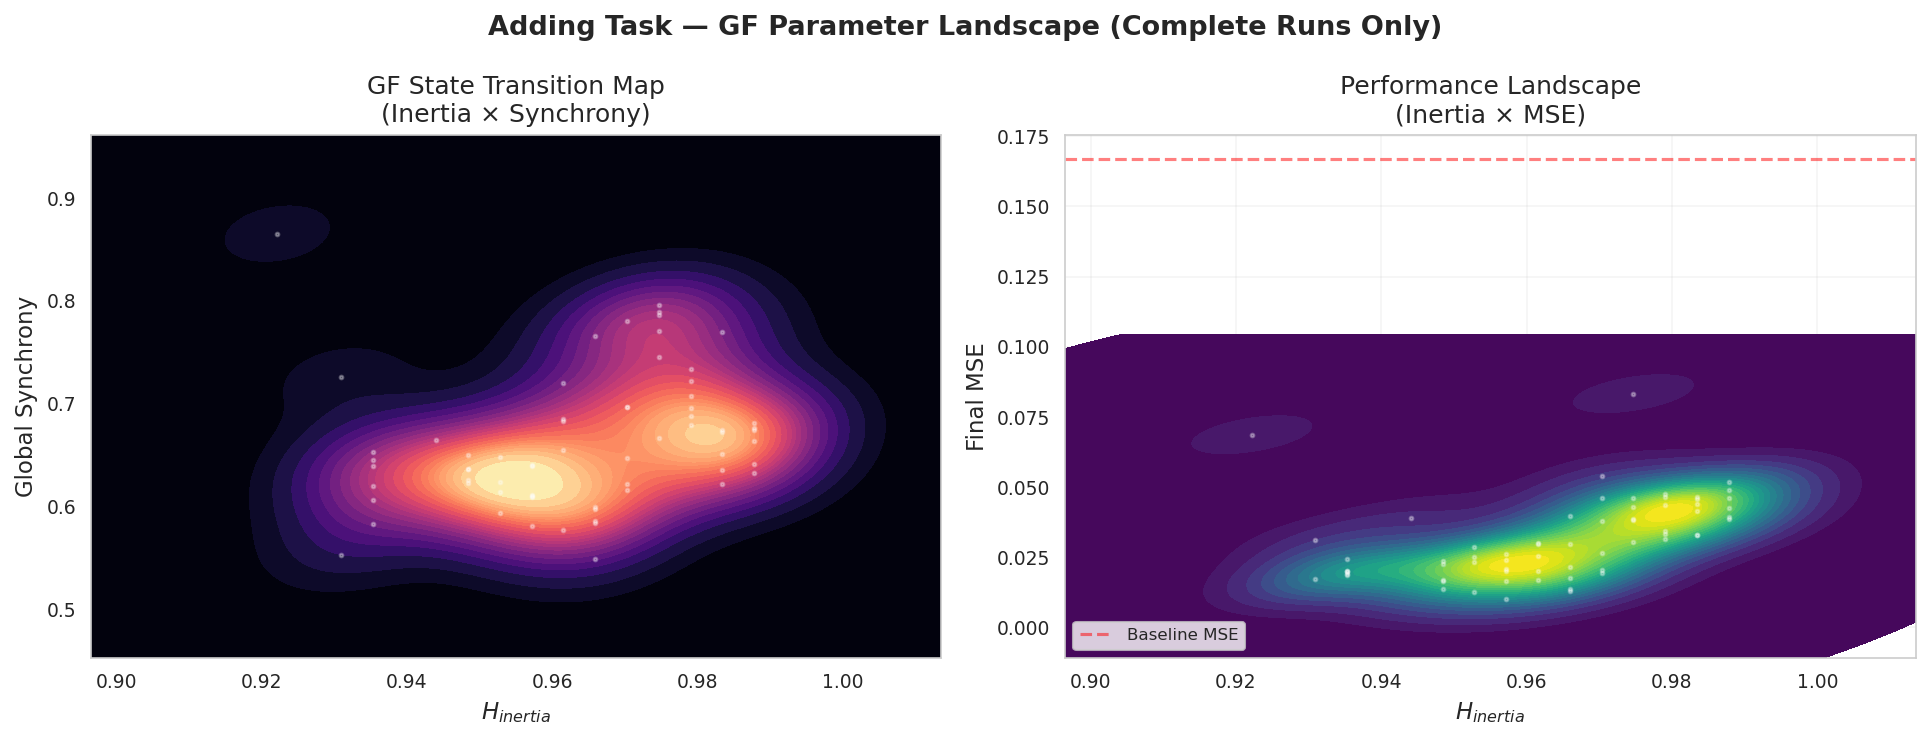

In [15]:
def plot_gf_state_map(df):
    complete = df[df.survived == 1]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Left: Inertia × Synchrony (GF state)
    sns.kdeplot(data=complete, x='inertia', y='sync',
                cmap='magma', fill=True, thresh=0, levels=25, ax=axes[0])
    axes[0].scatter(complete['inertia'], complete['sync'],
                    color='white', s=3, alpha=0.3)
    axes[0].set_title('GF State Transition Map\n(Inertia × Synchrony)', fontsize=12)
    axes[0].set_xlabel(PARAM_LABELS['inertia'])
    axes[0].set_ylabel('Global Synchrony')

    # Right: Inertia × MSE performance landscape
    sns.kdeplot(data=complete, x='inertia', y='mse',
                cmap='viridis', fill=True, thresh=0, levels=25, ax=axes[1])
    axes[1].scatter(complete['inertia'], complete['mse'],
                    color='white', s=3, alpha=0.3)
    axes[1].axhline(0.1667, color='red', linestyle='--', alpha=0.5, label='Baseline MSE')
    axes[1].set_title('Performance Landscape\n(Inertia × MSE)', fontsize=12)
    axes[1].set_xlabel(PARAM_LABELS['inertia'])
    axes[1].set_ylabel('Final MSE')
    axes[1].legend(fontsize=8)

    fig.suptitle('Adding Task — GF Parameter Landscape (Complete Runs Only)',
                 fontsize=13, fontweight='bold')
    fig.tight_layout()
    save_fig('gf_state_transition_map', fig)
    plt.show()

plot_gf_state_map(df)

### 4.9  Training Dynamics — Epoch Trajectories

Saved: epoch_trajectories


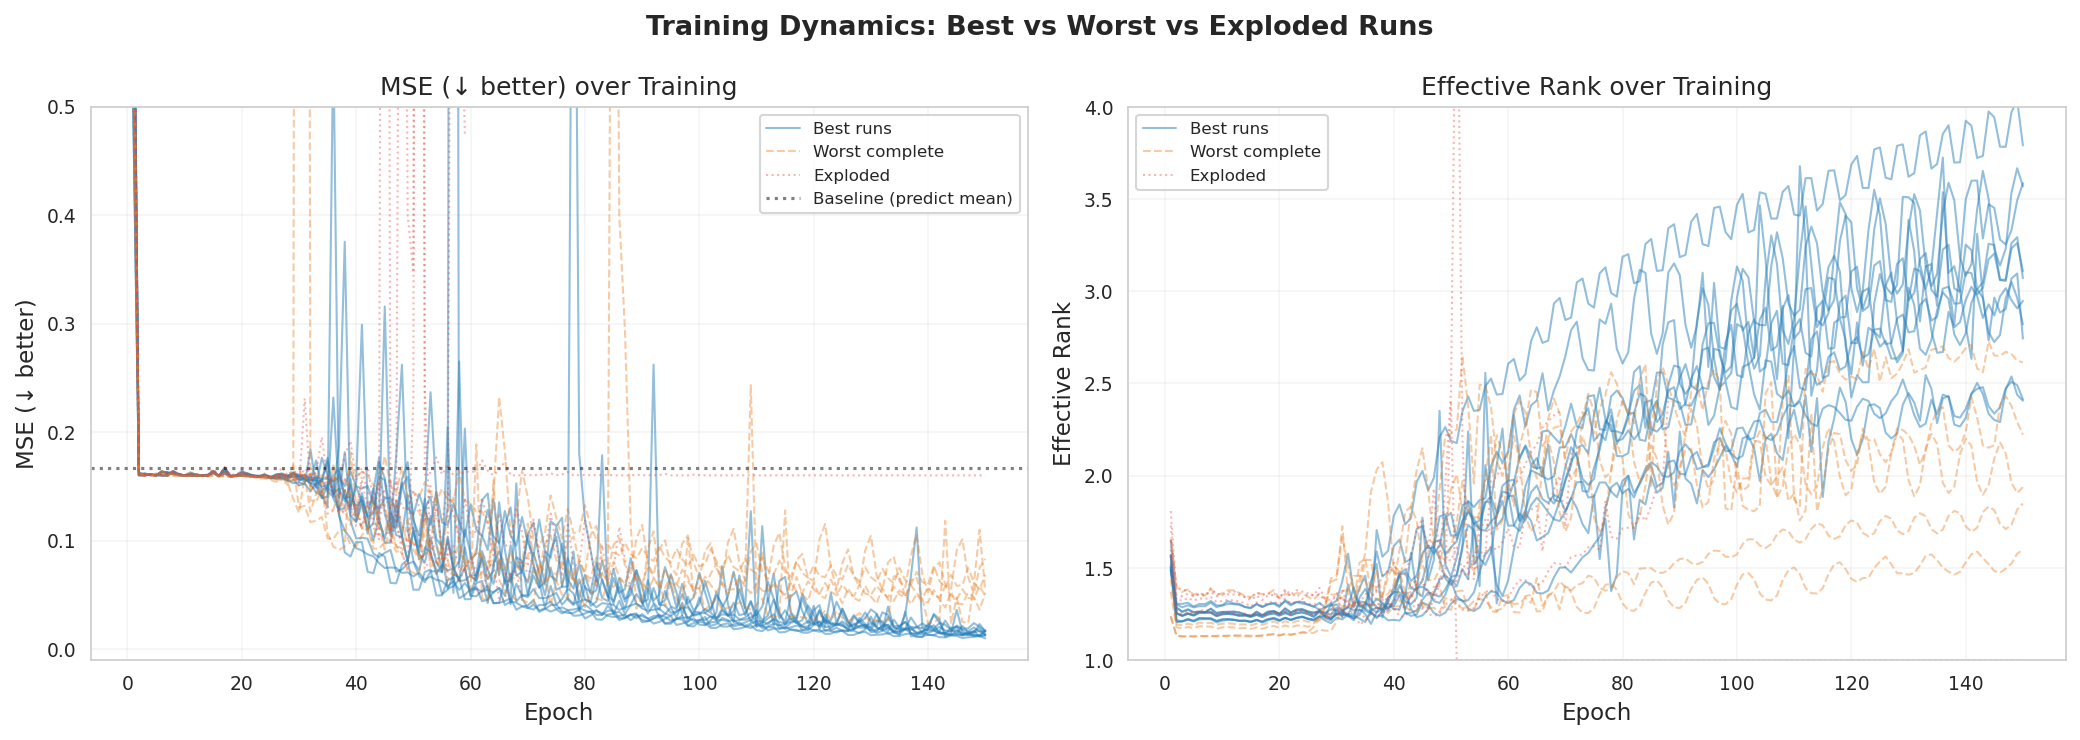

In [19]:
def plot_epoch_trajectories(raw, top_n=10, bottom_n=5):
    """
    Plot epoch-wise MSE and Rank trajectories for top/bottom performers.
    """
    complete_runs = [r for r in raw if r.get('status') == 'complete' and r.get('epochs')]
    complete_runs.sort(key=lambda r: r['epochs'][-1]['mse'])

    best   = complete_runs[:top_n]
    worst  = complete_runs[-bottom_n:] if len(complete_runs) > bottom_n else []
    explod = [r for r in raw if r.get('status') != 'complete' and r.get('epochs')]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, metric, ylabel in zip(
            axes,
            ['mse', 'rank'],
            ['MSE (↓ better)', 'Effective Rank']):

        for i, run in enumerate(best):
            vals = [e[metric] for e in run['epochs'] if metric in e]
            ax.plot(range(1, len(vals)+1), vals,
                    color=C['active'], alpha=0.5, linewidth=1,
                    label='Best runs' if i == 0 else '')

        for i, run in enumerate(worst):
            vals = [e[metric] for e in run['epochs'] if metric in e]
            ax.plot(range(1, len(vals)+1), vals,
                    color=C['sync'], alpha=0.4, linewidth=1, linestyle='--',
                    label='Worst complete' if i == 0 else '')

        for i, run in enumerate(explod[:5]):
            vals = [e[metric] for e in run['epochs'] if metric in e]
            ax.plot(range(1, len(vals)+1), vals,
                    color=C['exploded'], alpha=0.4, linewidth=1, linestyle=':',
                    label='Exploded' if i == 0 else '')

        # --- Y-AXIS MAX VALUE LOGIC ---
        if metric == 'mse':
            ax.axhline(0.1667, color='black', linestyle=':', alpha=0.5,
                       label='Baseline (predict mean)')
            # Clip at 0.5 to keep the 'Best' runs visible even if one run hits 10.0+
            ax.set_ylim(bottom=-0.01, top=0.5) 
        
        elif metric == 'rank':
            # Effective Rank cannot exceed the number of hidden units (128)
            ax.set_ylim(bottom=1, top=4)

        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{ylabel} over Training', fontsize=12)
        ax.legend(fontsize=8)

    fig.suptitle('Training Dynamics: Best vs Worst vs Exploded Runs',
                 fontsize=13, fontweight='bold')
    fig.tight_layout()
    save_fig('epoch_trajectories', fig)
    plt.show()
plot_epoch_trajectories(raw)

### 4.10  Metric Correlation Heatmap (Complete Runs)

Saved: metric_correlation_heatmap


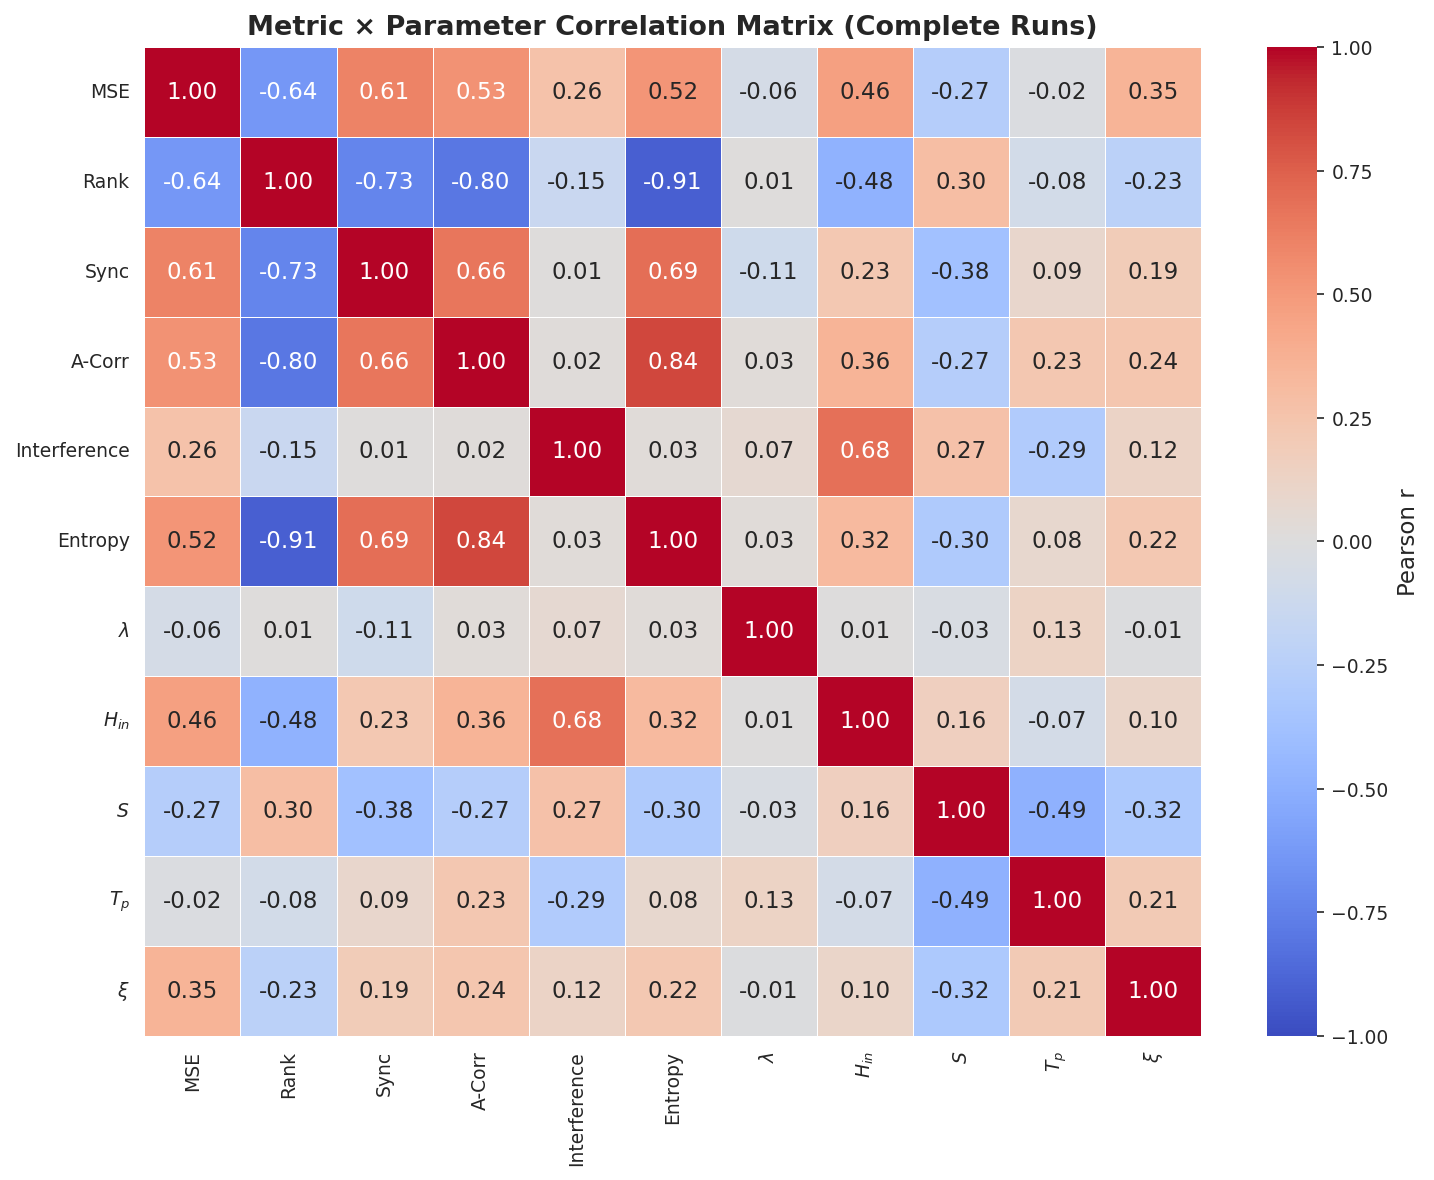

In [17]:
def plot_metric_correlations(df):
    complete = df[df.survived == 1]
    cols = ['mse', 'rank', 'sync', 'acorr', 'intf', 'entropy',
            'lambda', 'inertia', 'strength', 'period', 'jitter']
    cols = [c for c in cols if c in complete.columns]

    corr = complete[cols].corr()

    nice = {
        'mse':     'MSE',
        'rank':    'Rank',
        'sync':    'Sync',
        'acorr':   'A-Corr',
        'intf':    'Interference',
        'entropy': 'Entropy',
        'lambda':  r'$\lambda$',
        'inertia': r'$H_{in}$',
        'strength':r'$S$',
        'period':  r'$T_p$',
        'jitter':  r'$\xi$',
    }
    corr.index   = [nice.get(c, c) for c in corr.index]
    corr.columns = [nice.get(c, c) for c in corr.columns]

    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, vmin=-1, vmax=1,
                ax=ax, linewidths=0.4,
                cbar_kws={'label': 'Pearson r'})
    ax.set_title('Metric × Parameter Correlation Matrix (Complete Runs)',
                 fontsize=13, fontweight='bold')
    fig.tight_layout()
    save_fig('metric_correlation_heatmap', fig)
    plt.show()

plot_metric_correlations(df)

### 4.11  Rank × Sync Phase Portrait (coloured by Interference)

Saved: rank_sync_phase_portrait


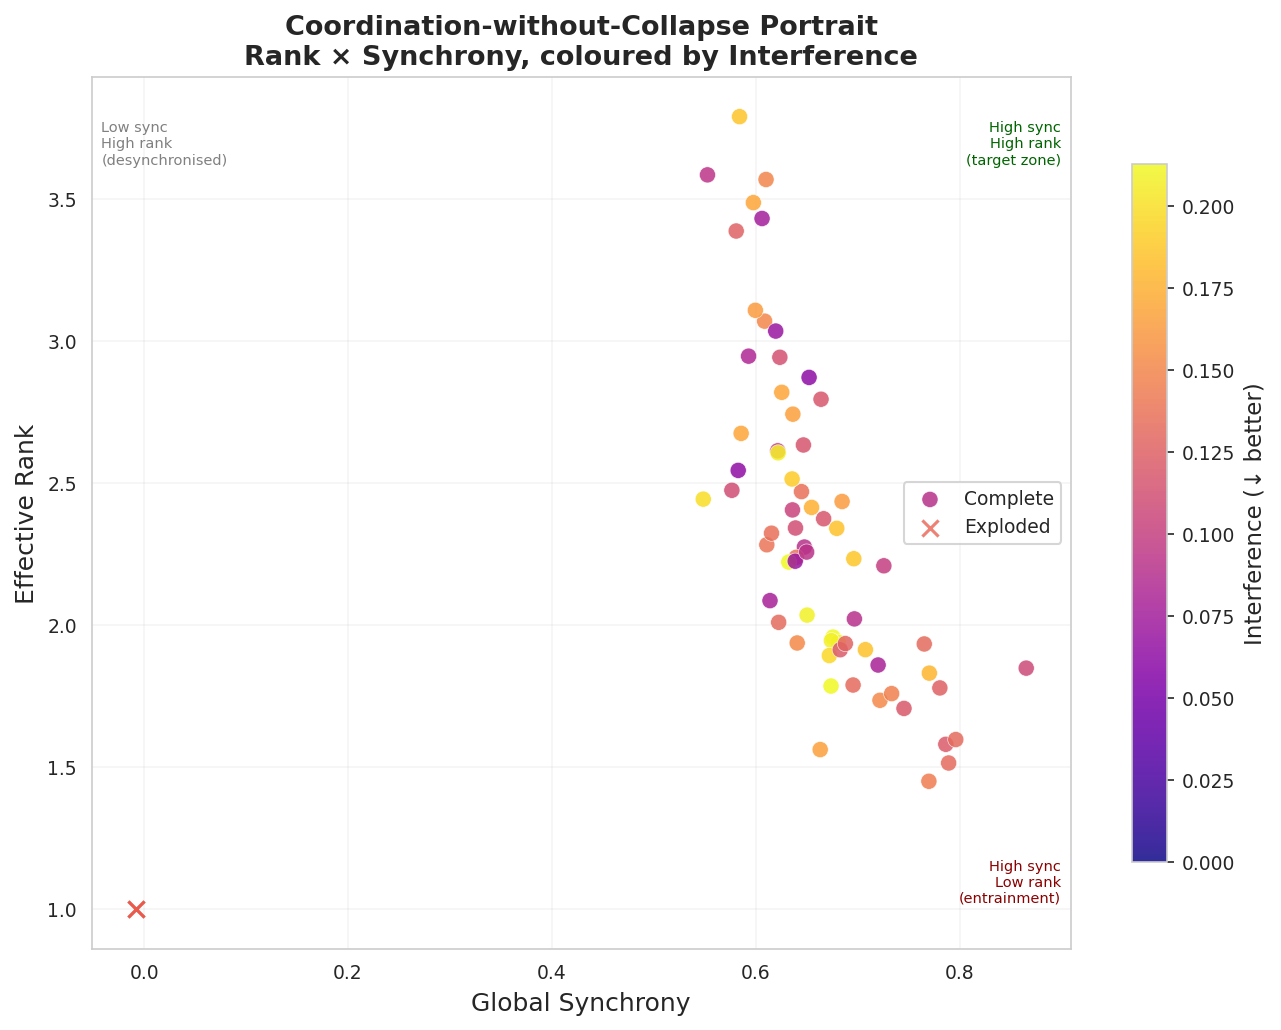

In [18]:
def plot_rank_sync_phase(df):
    """
    The coordination-without-collapse diagnostic.
    X: Synchrony, Y: Effective Rank, colour: Interference.
    Target: high rank + moderate sync + low interference.
    """
    complete = df[df.survived == 1].copy()
    exploded = df[df.survived == 0].copy()

    fig, ax = plt.subplots(figsize=(9, 7))

    sc = ax.scatter(complete['sync'], complete['rank'],
                    c=complete['intf'], cmap='plasma',
                    s=60, alpha=0.85, edgecolors='white', linewidths=0.3,
                    vmin=0, vmax=complete['intf'].quantile(0.95),
                    label='Complete', zorder=3)
    plt.colorbar(sc, ax=ax, label='Interference (↓ better)', shrink=0.8)

    ax.scatter(exploded['sync'], exploded['rank'],
               color=C['exploded'], marker='x', s=60, linewidths=1.5,
               alpha=0.7, label='Exploded', zorder=4)

    ax.set_xlabel('Global Synchrony', fontsize=12)
    ax.set_ylabel('Effective Rank', fontsize=12)
    ax.set_title('Coordination-without-Collapse Portrait\nRank × Synchrony, coloured by Interference',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)

    # Annotate quadrants
    xlim = ax.get_xlim(); ylim = ax.get_ylim()
    ax.text(xlim[0] + 0.01*(xlim[1]-xlim[0]),
            ylim[1] - 0.05*(ylim[1]-ylim[0]),
            'Low sync\nHigh rank\n(desynchronised)', fontsize=7, color='grey', va='top')
    ax.text(xlim[1] - 0.01*(xlim[1]-xlim[0]),
            ylim[1] - 0.05*(ylim[1]-ylim[0]),
            'High sync\nHigh rank\n(target zone)', fontsize=7, color='darkgreen',
            va='top', ha='right')
    ax.text(xlim[1] - 0.01*(xlim[1]-xlim[0]),
            ylim[0] + 0.05*(ylim[1]-ylim[0]),
            'High sync\nLow rank\n(entrainment)', fontsize=7, color='darkred',
            va='bottom', ha='right')

    fig.tight_layout()
    save_fig('rank_sync_phase_portrait', fig)
    plt.show()

plot_rank_sync_phase(df)

### 4.12  Strength Bifurcation — S vs All Metrics

Saved: strength_sweep_full


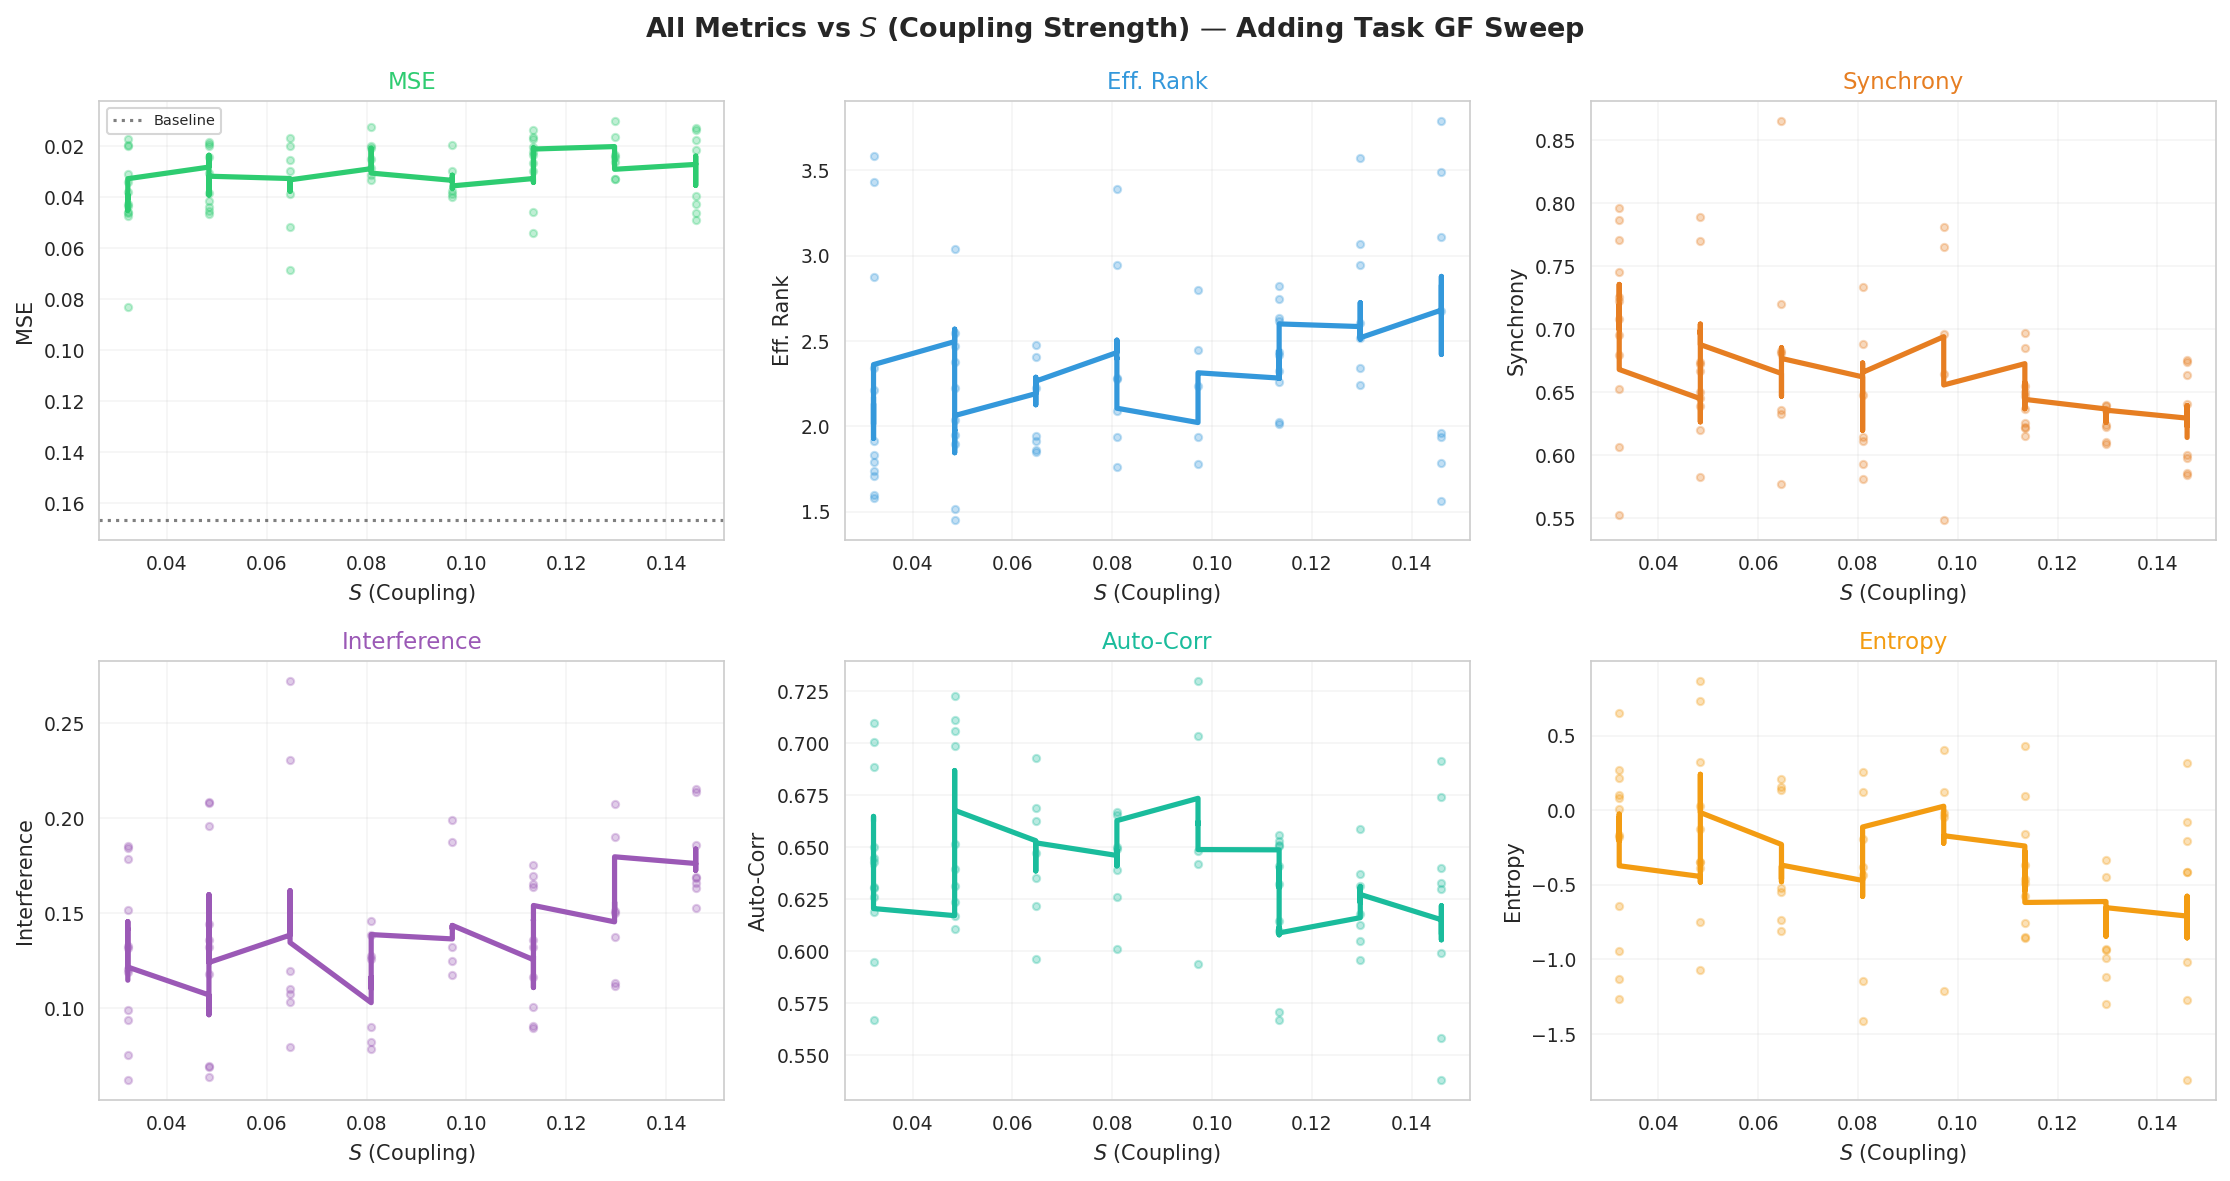

In [19]:
def plot_strength_sweep_full(df, window=6):
    """
    6-panel sweep of all representational metrics vs BASE_STRENGTH.
    Equivalent to the pMNIST H_INERTIA sweep but for the coupling parameter.
    """
    complete = df[df.survived == 1].sort_values('strength')

    metrics = [
        ('mse',     'MSE',          C['mse'],     True),
        ('rank',    'Eff. Rank',     C['rank'],    False),
        ('sync',    'Synchrony',     C['sync'],    False),
        ('intf',    'Interference',  C['intf'],    False),
        ('acorr',   'Auto-Corr',     C['acorr'],   False),
        ('entropy', 'Entropy',       C['entropy'], False),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for ax, (col, label, color, invert) in zip(axes, metrics):
        ax.scatter(complete['strength'], complete[col], color=color, s=12, alpha=0.3)
        if len(complete) >= window:
            rolled = complete[col].rolling(window=window, center=True).mean()
            ax.plot(complete['strength'], rolled, color=color, linewidth=2.5)
        if col == 'mse':
            ax.axhline(0.1667, color='black', linestyle=':', alpha=0.5, label='Baseline')
            ax.legend(fontsize=7)
        if invert:
            ax.invert_yaxis()
        ax.set_xlabel(PARAM_LABELS['strength'], fontsize=10)
        ax.set_ylabel(label, fontsize=10)
        ax.set_title(label, fontsize=11, color=color)

    fig.suptitle(r'All Metrics vs $S$ (Coupling Strength) — Adding Task GF Sweep',
                 fontsize=13, fontweight='bold')
    fig.tight_layout()
    save_fig('strength_sweep_full', fig)
    plt.show()

plot_strength_sweep_full(df)

## 5. Summary Statistics

In [20]:
complete = df[df.survived == 1]
exploded = df[df.survived == 0]

print('=' * 60)
print('ADDING TASK SOBOL SWEEP — SUMMARY')
print('=' * 60)
print(f'Total runs          : {len(df)}')
print(f'Complete            : {len(complete)}  ({100*len(complete)/len(df):.1f}%)')
print(f'Exploded / Failed   : {len(exploded)}  ({100*len(exploded)/len(df):.1f}%)')
print()
print('Complete runs — final metric statistics:')
print(complete[['mse','rank','sync','intf','acorr','entropy']].describe().round(4).to_string())
print()
print('Best run:')
best = complete.loc[complete['mse'].idxmin()]
for col in ['run_id','mse','rank','sync','intf','lambda','inertia','strength','period','jitter']:
    print(f'  {col:<12}: {best[col]}')
print()
print('Sobol ST ranking (MSE):')
st_pairs = sorted(zip(param_names, Si_mse['ST']), key=lambda x: -x[1])
for name, st in st_pairs:
    print(f'  {name:<20}: {st:.4f}')

ADDING TASK SOBOL SWEEP — SUMMARY
Total runs          : 96
Complete            : 66  (68.8%)
Exploded / Failed   : 30  (31.2%)

Complete runs — final metric statistics:
           mse     rank     sync     intf    acorr  entropy
count  66.0000  66.0000  66.0000  66.0000  66.0000  66.0000
mean    0.0313   2.3408   0.6623   0.1407   0.6396  -0.3809
std     0.0141   0.5601   0.0646   0.0456   0.0401   0.5763
min     0.0100   1.4511   0.5484   0.0621   0.5379  -1.8103
25%     0.0200   1.9193   0.6200   0.1104   0.6170  -0.8421
50%     0.0298   2.2666   0.6487   0.1343   0.6391  -0.3754
75%     0.0410   2.6295   0.6934   0.1694   0.6578   0.0889
max     0.0833   3.7901   0.8651   0.2723   0.7298   0.8659

Best run:
  run_id      : 11
  mse         : 0.010022374801337719
  rank        : 3.0704102516174316
  sync        : 0.6086066961288452
  intf        : 0.15107442438602448
  lambda      : 0.00145625
  inertia     : 0.9571875
  strength    : 0.1296875
  period      : 2875.0
  jitter      : 

## 6. Thesis-Ready Combined Figure

Saved: thesis_summary_figure


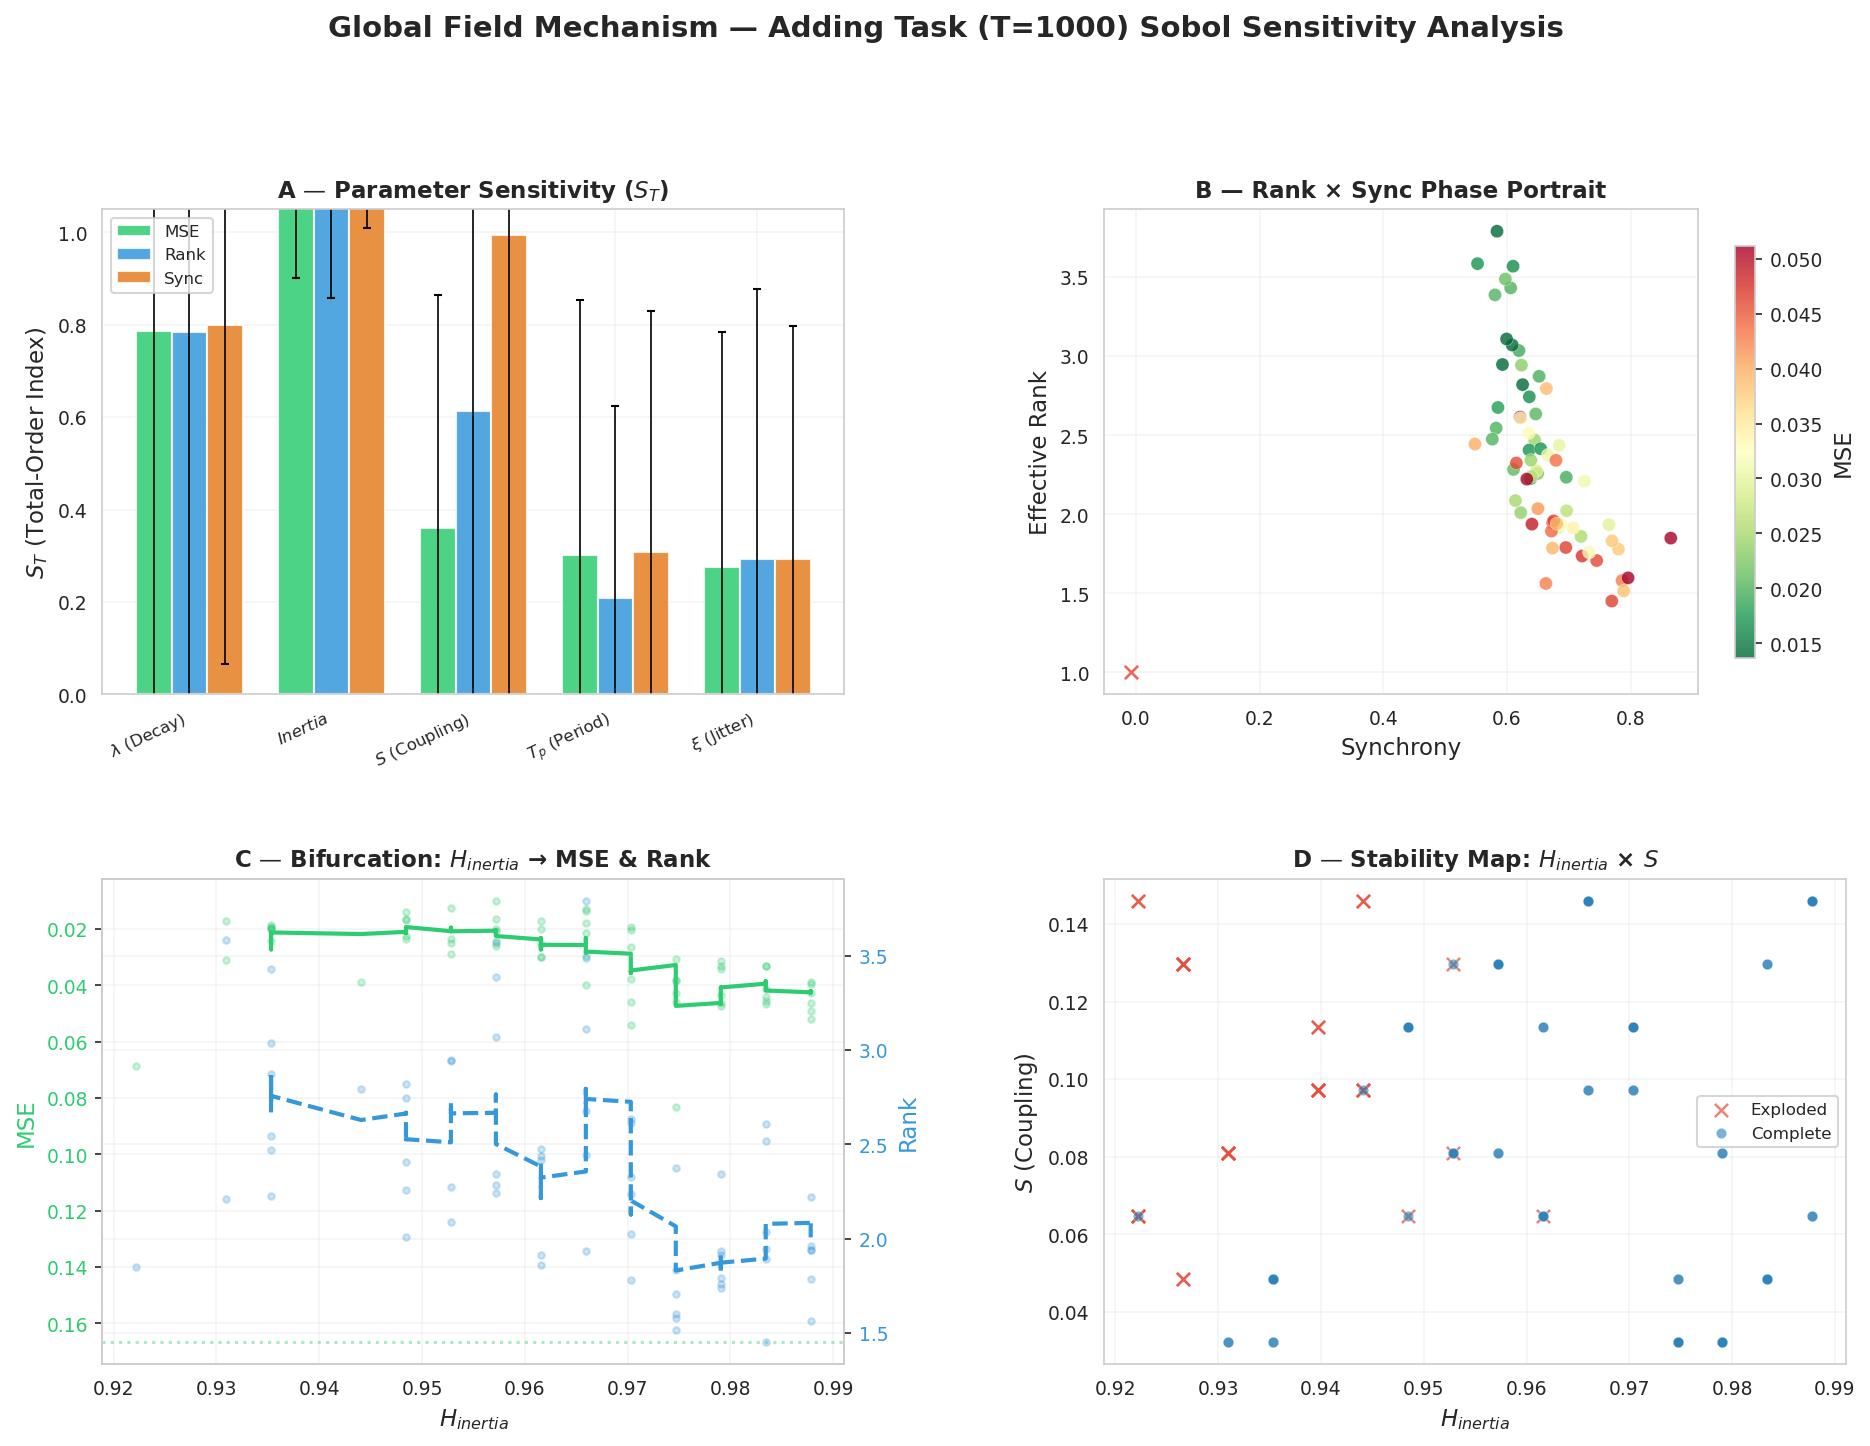

In [21]:
def plot_thesis_summary(df, Si_mse, Si_rank, Si_sync, nice_labels):
    """
    4-panel thesis figure:
    Top-left:  Sobol ST bars
    Top-right: Rank × Sync phase portrait
    Bottom-left:  Inertia bifurcation
    Bottom-right: Survival map
    """
    complete = df[df.survived == 1].sort_values('inertia')
    exploded = df[df.survived == 0]

    fig = plt.figure(figsize=(15, 10))
    gs  = gridspec.GridSpec(2, 2, hspace=0.38, wspace=0.35)

    # ── Panel A: Sobol ST ────────────────────────────────────────────────
    ax_a = fig.add_subplot(gs[0, 0])
    x    = np.arange(len(nice_labels))
    w    = 0.25
    for i, (Si, label, col) in enumerate([
            (Si_mse,  'MSE',      C['mse']),
            (Si_rank, 'Rank',     C['rank']),
            (Si_sync, 'Sync',     C['sync'])]):
        st = np.clip(Si['ST'], 0, None)
        ax_a.bar(x + (i-1)*w, st, w, label=label, color=col, alpha=0.85,
                 yerr=Si['ST_conf'], capsize=2, error_kw={'linewidth':0.8})
    ax_a.set_xticks(x)
    ax_a.set_xticklabels(nice_labels, rotation=25, ha='right', fontsize=8)
    ax_a.set_ylabel('$S_T$ (Total-Order Index)')
    ax_a.set_title('A — Parameter Sensitivity ($S_T$)', fontsize=11, fontweight='bold')
    ax_a.legend(fontsize=8)
    ax_a.set_ylim(0, 1.05)

    # ── Panel B: Phase portrait ──────────────────────────────────────────
    ax_b = fig.add_subplot(gs[0, 1])
    sc = ax_b.scatter(complete['sync'], complete['rank'],
                      c=complete['mse'], cmap='RdYlGn_r', s=40,
                      alpha=0.8, edgecolors='white', linewidths=0.2,
                      vmin=complete['mse'].quantile(0.05),
                      vmax=complete['mse'].quantile(0.95))
    ax_b.scatter(exploded['sync'], exploded['rank'],
                 color=C['exploded'], marker='x', s=40, linewidths=1.2, alpha=0.6)
    plt.colorbar(sc, ax=ax_b, label='MSE', shrink=0.85)
    ax_b.set_xlabel('Synchrony')
    ax_b.set_ylabel('Effective Rank')
    ax_b.set_title('B — Rank × Sync Phase Portrait', fontsize=11, fontweight='bold')

    # ── Panel C: Bifurcation ─────────────────────────────────────────────
    ax_c  = fig.add_subplot(gs[1, 0])
    ax_c2 = ax_c.twinx()
    w = 8
    ax_c.scatter(complete['inertia'], complete['mse'], color=C['mse'], s=10, alpha=0.25)
    if len(complete) >= w:
        ax_c.plot(complete['inertia'],
                  complete['mse'].rolling(w, center=True).mean(),
                  color=C['mse'], linewidth=2)
    ax_c.axhline(0.1667, color=C['mse'], linestyle=':', alpha=0.4)
    ax_c.set_ylabel('MSE', color=C['mse'])
    ax_c.invert_yaxis()
    ax_c.tick_params(axis='y', labelcolor=C['mse'])
    ax_c2.scatter(complete['inertia'], complete['rank'], color=C['rank'], s=10, alpha=0.25)
    if len(complete) >= w:
        ax_c2.plot(complete['inertia'],
                   complete['rank'].rolling(w, center=True).mean(),
                   color=C['rank'], linewidth=2, linestyle='--')
    ax_c2.set_ylabel('Rank', color=C['rank'])
    ax_c2.tick_params(axis='y', labelcolor=C['rank'])
    ax_c.set_xlabel(PARAM_LABELS['inertia'])
    ax_c.set_title(r'C — Bifurcation: $H_{inertia}$ → MSE & Rank', fontsize=11, fontweight='bold')

    # ── Panel D: Survival map ────────────────────────────────────────────
    ax_d = fig.add_subplot(gs[1, 1])
    ax_d.scatter(exploded['inertia'], exploded['strength'],
                 color=C['exploded'], marker='x', s=40, linewidths=1.2,
                 alpha=0.7, label='Exploded')
    ax_d.scatter(complete['inertia'],  complete['strength'],
                 color=C['active'], s=25, alpha=0.6, edgecolors='white',
                 linewidths=0.2, label='Complete')
    ax_d.set_xlabel(PARAM_LABELS['inertia'])
    ax_d.set_ylabel(PARAM_LABELS['strength'])
    ax_d.set_title(r'D — Stability Map: $H_{inertia}$ × $S$', fontsize=11, fontweight='bold')
    ax_d.legend(fontsize=8)

    fig.suptitle('Global Field Mechanism — Adding Task (T=1000) Sobol Sensitivity Analysis',
                 fontsize=14, fontweight='bold', y=1.01)
    save_fig('thesis_summary_figure', fig)
    plt.show()

plot_thesis_summary(df, Si_mse, Si_rank, Si_sync, nice_labels)